<a href="https://colab.research.google.com/github/tanzim10/maveric/blob/obj5/MRO_w_sinr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mobility Robustness Optimization(MRO)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Pre-requisites and Helper Function



In [ ]:
from collections import defaultdict
from operator import itemgetter
from typing import Any, Dict, List, Tuple
from typing import Final

import numpy as np
import pandas as pd
import math
import logging

In [ ]:
logger = logging.getLogger(__name__)

In [ ]:
!pip install gpytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.7/277.7 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.3/176.3 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
from __future__ import annotations

import logging
import os
import pickle
from enum import Enum
from typing import Any, Dict, List, Optional, Tuple

import gpytorch
import numpy as np
import pandas as pd
import torch
from contextlib import contextmanager

In [ ]:
def lon_lat_to_bing_tile(longitude, latitude, level, tile_pixels=256):
    zoom_factor = 1 << level
    pixel_x = longitude_to_world_pixel(longitude, zoom_factor)
    x = int(map_clip(np.floor(pixel_x / tile_pixels), 0, tile_pixels * zoom_factor - 1))
    pixel_y = latitude_to_world_pixel(latitude, zoom_factor)
    y = int(map_clip(np.floor(pixel_y / tile_pixels), 0, zoom_factor - 1))
    return x, y

In [ ]:
def bing_tile_to_center_df_row(row, level):
    y, x = bing_tile_to_center(row.loc_x, row.loc_y, level)
    row.loc_x = x
    row.loc_y = y
    return row

In [ ]:
def bing_tile_to_center(x, y, level, tile_pixels=256):
    """Get the center coordinate as [latitude, longitude]
    for a given tile.

    Arguments:
        x: The tile x coordinate.
        y: The tile y coordinate.
        level: The zoom level of the tile.

    Returns:
        An array with [latitude, longitude] coordinates
        of the center of the given tile.
    """
    zoom_factor = 1 << level
    xwidth = 360.0 / zoom_factor
    out = []
    out.append(
        (
            y_to_latitude(True, y, zoom_factor, tile_pixels)
            + y_to_latitude(False, y, zoom_factor, tile_pixels)
        )
        / 2
    )
    out.append(xwidth * (x + 0.5) - 180)
    return out

In [ ]:
def y_to_latitude(lower_bound, y, zoom_factor, tile_pixels=256):
    """Convert a y tile coordinate to a latitude coordinate.

    Arguments:
        lower_bound: A bool whether to use the lower edge of the tile.
        y: The y tile coordinate.
        zoom_factor: The zoom factor for the tile's zoom level.

    Returns:
        Degrees latitude for either the upper or lower edge of the tile.
    """
    if lower_bound:
        y = y + 1
    yt = (y * 1.0) / zoom_factor
    k = np.exp((yt - 0.5) * 4 * np.pi)
    sin_latitude = (k - 1) / (k + 1)
    latitude = np.arcsin(sin_latitude)
    latitude_degrees = latitude * 180.0 / np.pi
    return -latitude_degrees


In [ ]:
def lon_lat_to_bing_tile_df_row(row, level):
    x, y = lon_lat_to_bing_tile(row.loc_x, row.loc_y, level)
    row.loc_x = x
    row.loc_y = y
    return row

In [ ]:
def map_clip(val, min_val, max_val):
    """Clip val to [min_val, max_val].

    Arguments:
        val: A value to be clipped.
        min_val: The minimum allowed value.
        max_val: The maximum allowed value.

    Returns:
        Value clipped to the range of [min_val, max_val].
    """
    return np.max([min_val, np.min([val, max_val])])


In [ ]:
def longitude_to_world_pixel(longitude, zoom_factor, tile_pixels=256):
    """Convert degrees longitude to world pixel coordinates.

    World pixel coordinates span the whole range of longitude
    coordinates, whereas tile pixel coordinates mark a position
    within a tile. Longitude pixels have their origin coordinate at the
    westernmost valid longitude coordinate: -180 deg,
    and extend to their easternmost coordinate: 180 deg.

    Arguments:
        longitude: Longitude coordinate in degrees.
        zoom_factor: Zoom factor for the given zoom level.

    Returns:
        A world pixel coordinate in longitudinal direction, a floating-point
    """
    longitude = map_clip(longitude, -180.0, 180.0)
    pixel_x = ((longitude + 180.0) / 360.0) * (tile_pixels * zoom_factor)
    return pixel_x


def latitude_to_world_pixel(latitude, zoom_factor, tile_pixels=256):
    """Convert degrees latitude to world pixel coordinates.

    World pixel coordinates span the whole range of latitude
    coordinates, whereas tile pixel coordinates mark a position
    within a tile. Latitude pixels have their origin coordinate at the
    northernmost valid latitude coordinate: 85.05112878 deg,
    and extent to their southernmost coordinate: -85.05112878 deg.

    Arguments:
        latitude: Latitude in degrees.
        zoom_factor: Zoom factor for the given zoom level.

    Returns:
        A world pixel coordinate in latitudinal direction, a floating-point
    """
    latitude = map_clip(latitude, -85.05112878, 85.05112878)
    sin_latitude = np.sin(latitude * np.pi / 180.0)

    pixel_y = (0.5 - np.log((1 + sin_latitude) / (1 - sin_latitude)) / (4 * np.pi)) * (
        tile_pixels * zoom_factor
    )
    return pixel_y


In [ ]:
@contextmanager
def atomic_write(file_path: str, mode: str):
    """Write to unique temp file, then overwrite original"""
    try:
        tmp_file_path = f"{file_path}.{uuid1()}.tmp"
        file = open(tmp_file_path, mode)
        yield file
    finally:
        file.flush()
        fsync(file.fileno())
        file.close()
        replace(tmp_file_path, file_path)

In [ ]:
RADIUS_EARTH_EQUATOR_KM = 6378.137
CIRC_KM_TO_DEG_LAT: float = 180.0 / (math.pi * RADIUS_EARTH_EQUATOR_KM)

LATENT_BACKGROUND_NOISE_DB = -150

ANTENNA_GAIN: Final[str] = "antenna_gain"
CELL_AZ_DEG: Final[str] = "cell_az_deg"
CELL_CARRIER_FREQ_MHZ: Final[str] = "cell_carrier_freq_mhz"
CELL_EL_DEG: Final[str] = "cell_el_deg"
CELL_ID: Final[str] = "cell_id"
CELL_LAT: Final[str] = "cell_lat"
CELL_LON: Final[str] = "cell_lon"
CELL_RXPWR_DBM: Final[str] = "cell_rxpwr_dbm"
CELL_TXPWR_DBM: Final[str] = "cell_txpwr_dbm"
HRX: Final[str] = "hRx"
HTX: Final[str] = "hTx"
LAT: Final[str] = "lat"
LOC_X: Final[str] = "loc_x"
LOC_Y: Final[str] = "loc_y"
LOG_DISTANCE: Final[str] = "log_distance"
LON: Final[str] = "lon"
RELATIVE_BEARING: Final[str] = "relative_bearing"
RELATIVE_TILT_SQUARED: Final[str] = "relative_tilt_squared"
RELATIVE_TILT: Final[str] = "relative_tilt"
RSRP_DBM: Final[str] = "rsrp_dbm"
RXPOWER_DBM: Final[str] = "rxpower_dbm"
RXPOWER_STDDEV_DBM: Final[str] = "rxpower_stddev_dbm"
SIM_IDX: Final[str] = "sim_idx"
SINR_DB: Final[str] = "sinr_db"

In [ ]:

class NormMethod(Enum):
    MINMAX = "minmax"  # {value - min}/{max - min}
    ZSCORE = "zscore"  # {value - mean}/{std}


class ExactGPModel(gpytorch.models.ExactGP):
    # We will use the simplest form of GP model, exact inference
    def __init__(self, train_x, train_y, likelihood):
        super(ExactGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean(batch_shape=torch.Size([1]))
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(batch_shape=torch.Size([1])),
            batch_shape=torch.Size([1]),
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


class BayesianDigitalTwin:
    def __init__(
        self,
        data_in: List[pd.DataFrame],
        x_columns: List[str],
        y_columns: List[str],
        norm_method: NormMethod = NormMethod.MINMAX,
        x_max: Optional[Dict[str, float]] = None,
        x_min: Optional[Dict[str, float]] = None,
    ):
        """
        `data_in` is a list of Pandas dataframes, where each one corresponds to
        training data for one cell. `stats` is a list of Pandas dataframes, of the
        same length as `data_in`, where each contains statistics of the corresponding
        cell, to be used for pre-training normalization and post-prediction de-normalization.

        `x_columns` specifies the columns to train on, and `y_columns` specifies the columns
        to predict. These must be present in `data_in`.

        `x_max` and `x_min` contains optional user-specified max and min values for columns
        in `data_in` -- if these are provided, they are used instead of observed ranges
        during input pre-training normalization.

        `data_in` and `stats` may be constructed using `get_percell_data`.
        """
        self.is_cuda = False
        if torch.cuda.is_available():
            torch.cuda.set_device(0)
            self.is_cuda = True

        self.cell_ids = [data_in_cell.cell_id.unique()[0] for data_in_cell in data_in]
        self.num_cells = len(self.cell_ids)
        self.x_columns = x_columns
        self.y_columns = y_columns
        self.num_features = len(self.x_columns)

        self.cell_stats = [cell_data.describe() for cell_data in data_in]
        self.xmeans = []
        self.xstds = []
        self.xmax = []
        self.xmin = []
        self.ymeans = []
        self.ystds = []

        self.norm_method = norm_method

        # Create Gaussian Process Regression (GPR) model; independent outputs.
        # produce normalization ranges
        for m in range(self.num_cells):
            self.xmax.append(self.cell_stats[m].loc["max", self.x_columns])
            self.xmin.append(self.cell_stats[m].loc["min", self.x_columns])
            # if explicitly provided, replace and use instead of empirical ranges
            if x_max:
                for k, v in x_max.items():
                    if k in self.x_columns:
                        self.xmax[m][k] = v
            if x_min:
                for k, v in x_min.items():
                    if k in self.x_columns:
                        self.xmin[m][k] = v
            self.xmeans.append(self.cell_stats[m].loc["mean", self.x_columns])
            self.xstds.append(self.cell_stats[m].loc["std", self.x_columns])
            self.ymeans.append(self.cell_stats[m].loc["mean", self.y_columns])
            self.ystds.append(self.cell_stats[m].loc["std", self.y_columns])

        # create training tensors
        train_X, train_Y = self._create_training_tensors(data_in)

        # initialize likelihood and model
        likelihood = gpytorch.likelihoods.GaussianLikelihood(
            batch_shape=torch.Size([self.num_cells])
        )

        self.model = ExactGPModel(train_X, train_Y, likelihood)

    def _create_training_tensors(
        self,
        data_in: List[pd.DataFrame],
    ):
        n_train = data_in[0].shape[0]

        # Get train_X and train_Y, create training tensors
        train_X = torch.zeros(
            [self.num_cells, n_train, self.num_features], dtype=torch.float32
        )

        train_Y = torch.zeros([self.num_cells, n_train], dtype=torch.float32)

        for m in range(self.num_cells):
            if self.norm_method == NormMethod.MINMAX:
                train_x_cell = (data_in[m][self.x_columns] - self.xmin[m]) / (
                    self.xmax[m] - self.xmin[m]
                )
            elif self.norm_method == NormMethod.ZSCORE:
                train_x_cell = (
                    data_in[m][self.x_columns] - self.xmeans[m]
                ) / self.xstds[m]

            train_X_cell = torch.tensor(
                train_x_cell.iloc[:, :].values, dtype=torch.float32
            )

            train_y_cell = (data_in[m][self.y_columns] - self.ymeans[m]) / self.ystds[m]
            train_Y_cell = torch.tensor(
                train_y_cell.iloc[:, :].values, dtype=torch.float32
            )

            train_X[m] = train_X_cell.reshape(shape=(1, -1, self.num_features))
            train_Y[m] = torch.transpose(train_Y_cell, 0, 1)

        return train_X, train_Y

    @staticmethod
    def preprocess_ue_training_data(
        ue_training_data_df: pd.DataFrame, topology_df: pd.DataFrame
    ) -> Dict:
        """Preprocess UE data before training

        ue_training_data_df -   dataframe containing location data as well as config
        topology_df -           dataframe containing the static cell topology
        """

        topology_df.reset_index(drop=True, inplace=True)

        # feature engineering -- add relative bearing and distance
        for i in ue_training_data_df.index:
            cell_topology = topology_df[
                topology_df.cell_id == ue_training_data_df.at[i, "cell_id"]
            ]

            # change lon/lat to loc_x/loc_y in ue data
            ue_training_data_df.at[i, "loc_x"] = ue_training_data_df.at[i, "lon"]
            ue_training_data_df.at[i, "loc_y"] = ue_training_data_df.at[i, "lat"]

            # add the topology columns to training data
            ue_training_data_df.at[i, "cell_lat"] = cell_topology.cell_lat.values[0]
            ue_training_data_df.at[i, "cell_lon"] = cell_topology.cell_lon.values[0]
            ue_training_data_df.at[i, "cell_az_deg"] = cell_topology.cell_az_deg.values[
                0
            ]
            ue_training_data_df.at[
                i, "cell_carrier_freq_mhz"
            ] = cell_topology.cell_carrier_freq_mhz.values[0]

            # engineer and add the log distance and relative bearing features
            ue_training_data_df.at[i, "log_distance"] = np.log(
                1
                + 1000
                * GISTools.dist(
                    (
                        ue_training_data_df.at[i, "cell_lat"],
                        ue_training_data_df.at[i, "cell_lon"],
                    ),
                    (
                        ue_training_data_df.at[i, "lat"],
                        ue_training_data_df.at[i, "lon"],
                    ),
                )
            )
            ue_training_data_df.at[i, "relative_bearing"] = GISTools.rel_bearing(
                ue_training_data_df.at[i, "cell_az_deg"],
                GISTools.convert_bearing_0_to_360(
                    GISTools.get_bearing(
                        (
                            ue_training_data_df.at[i, "lat"],
                            ue_training_data_df.at[i, "lon"],
                        ),
                        (
                            ue_training_data_df.at[i, "cell_lat"],
                            ue_training_data_df.at[i, "cell_lon"],
                        ),
                    )
                ),
            )

        ue_training_data_df.cell_id = ue_training_data_df.cell_id
        return {k: v for k, v in ue_training_data_df.groupby("cell_id")}

    @staticmethod
    def preprocess_ue_prediction_data(
        ue_data_df: pd.DataFrame,
        config_df: pd.DataFrame,
        topology_df: pd.DataFrame,
    ) -> Dict:
        """Preprocess UE data before prediction

        ue_data_df -    dataframe containing the cell_id, location data and optionally
                        mock_ue_id/tick
        config_df -     dataframe containing cell config
        topology_df -   dataframe containing dataframe containing the static cell topology
        """

        config_df.reset_index(drop=True, inplace=True)

        # feature engineering -- add relative bearing and distance
        for i in ue_data_df.index:
            # pull the config and topology for this cell
            cell_config = config_df[config_df.cell_id == ue_data_df.at[i, "cell_id"]]
            cell_topology = topology_df[
                topology_df.cell_id == ue_data_df.at[i, "cell_id"]
            ]

            # change lon/lat to loc_x/loc_y in ue data
            ue_data_df.at[i, "loc_x"] = ue_data_df.at[i, "lon"]
            ue_data_df.at[i, "loc_y"] = ue_data_df.at[i, "lat"]

            # add the topology columns to ue data
            ue_data_df.at[i, "cell_lat"] = cell_topology.cell_lat.values[0]
            ue_data_df.at[i, "cell_lon"] = cell_topology.cell_lon.values[0]
            ue_data_df.at[i, "cell_az_deg"] = cell_topology.cell_az_deg.values[0]
            ue_data_df.at[
                i, "cell_carrier_freq_mhz"
            ] = cell_topology.cell_carrier_freq_mhz.values[0]

            # add the config columns to ue data
            ue_data_df.at[i, "cell_el_deg"] = cell_config.cell_el_deg.values[0]

            # engineer and add the log distance and relative bearing features
            ue_data_df.at[i, "log_distance"] = np.log(
                1
                + 1000
                * GISTools.dist(
                    (
                        ue_data_df.at[i, "cell_lat"],
                        ue_data_df.at[i, "cell_lon"],
                    ),
                    (ue_data_df.at[i, "lat"], ue_data_df.at[i, "lon"]),
                )
            )
            ue_data_df.at[i, "relative_bearing"] = GISTools.rel_bearing(
                ue_data_df.at[i, "cell_az_deg"],
                GISTools.convert_bearing_0_to_360(
                    GISTools.get_bearing(
                        (
                            ue_data_df.at[i, "lat"],
                            ue_data_df.at[i, "lon"],
                        ),
                        (
                            ue_data_df.at[i, "cell_lat"],
                            ue_data_df.at[i, "cell_lon"],
                        ),
                    )
                ),
            )

        ue_data_df.cell_id = ue_data_df.cell_id
        return {k: v for k, v in ue_data_df.groupby("cell_id")}

    @staticmethod
    def load_model_map_from_pickle(
        model_file_path: str,
    ) -> Dict[str, BayesianDigitalTwin]:
        # load trained digital twin model map
        try:
            with open(model_file_path, "rb") as pickle_file:
                model_map: Dict[str, BayesianDigitalTwin] = pickle.load(pickle_file)
                return model_map
        except Exception as e:
            logger.exception(
                f"Exception occurred while loading digital twin model from file: {model_file_path}"
            )
            raise e

    @staticmethod
    def save_model_map_to_pickle(
        model_file_path: str,
        model_map: Dict[str, BayesianDigitalTwin],
    ) -> None:
        """Saving mapping of models to file"""
        try:
            with atomic_write(model_file_path, "wb") as pickle_file:
                pickle.dump(model_map, pickle_file)
            logger.info(f"Successfully saved model to file: {model_file_path}")
        except Exception as e:
            logger.exception(
                f"Exception occurred writing digital twin model to file: {model_file_path}"
            )
            raise e

    @staticmethod
    def split_training_and_test_data(
        data_in: pd.DataFrame,
        n_sim: int,
        alpha: float,
    ) -> Tuple[List[pd.DataFrame], List[pd.DataFrame], pd.DataFrame, Any]:
        """Split the simulation data groups into test and training sets.

        data_in: aggregated simulation data in the form of a dataframe (test+train)
        n_sim: number of simulations aggregated in data_in
        alpha: percent of simulation runs used for training

        Each row of `data_in` corresponds to one pixel, and the columns
        are assumed to contain :
            - settings corresponding to one or more cells, with column names
            `settng_name_<n>` for different settings of interest and where
            n refers to the index of a cell in the modeled cluster.
            - `rx_loc1` and `rx_loc2`, the geo-coordinates for the pixel
            - `rxpower_dbm_<n>`, the received powers for the cell with index n
            - `rsrp_dbm` is the max power and `cell_id` is the cell index of that cell
            - `sim_idx` is the simulation index

        Example:
        ['cell_azimuth_deg_1', 'cell_azimuth_deg_2', 'cell_azimuth_deg_3',
        'cell_elec_tilt_deg_1', 'cell_elec_tilt_deg_2', 'cell_elec_tilt_deg_3',
        'cell_mech_tilt_deg_1', 'cell_mech_tilt_deg_2', 'cell_mech_tilt_deg_3',
        'cell_txpower_dbm_1', 'cell_txpower_dbm_2', 'cell_txpower_dbm_3',
        'rxpower_dbm_1', 'rxpower_dbm_2', 'rxpower_dbm_3', 'rsrp_dbm',
        'sinr_db', 'cell_id', 'rx_loc1', 'rx_loc2', 'sim_idx']

        """
        n_training_group = np.max([int(alpha * 0.01 * n_sim), 1])
        n_test_group = n_sim - n_training_group
        logger.info(
            f"Splitting data into {n_training_group} training and {n_test_group} test groups..."
        )
        training_data = data_in[data_in[constants.SIM_IDX] > n_test_group].reset_index(
            drop=True
        )
        test_data = data_in[data_in[constants.SIM_IDX] <= n_test_group].reset_index(
            drop=True
        )
        stats = data_in.describe(include="all")
        return training_data, test_data, stats, n_training_group

    @staticmethod
    def create_prediction_frames(
        site_config_df: pd.DataFrame,
        prediction_frame_template: pd.DataFrame,
    ) -> Dict[str, pd.DataFrame]:
        """
        `site_config_df` : 1 unique cell per row, contains at least the columns
            [cell_lat, cell_lon, cell_el_deg, cell_az_deg, cell_id]
            Assumption : `bayesian_digital_twin` was trained with respect to `site_config_df`
        `prediction_frame_template` : 1 prediction point per row, contains columsn [loc_x, loc_y]
            e.g. loc_x is longitude, and loc_y is latitude
        """

        prediction_dfs: Dict[str, pd.DataFrame] = {}

        for c in site_config_df.itertuples():
            prediction_df = prediction_frame_template.copy()

            prediction_df[constants.CELL_LAT] = c.cell_lat
            prediction_df[constants.CELL_LON] = c.cell_lon
            prediction_df[constants.CELL_EL_DEG] = c.cell_el_deg
            prediction_df[constants.CELL_ID] = c.cell_id
            prediction_df[constants.CELL_CARRIER_FREQ_MHZ] = c.cell_carrier_freq_mhz
            prediction_df[constants.HTX] = c.hTx
            prediction_df[constants.HRX] = c.hRx

            prediction_df[constants.LOG_DISTANCE] = [
                GISTools.get_log_distance(
                    c.cell_lat,
                    c.cell_lon,
                    lat,
                    lon,
                )
                for lat, lon in zip(
                    prediction_frame_template.loc_y, prediction_frame_template.loc_x
                )
            ]

            prediction_df[constants.RELATIVE_BEARING] = [
                GISTools.get_relative_bearing(
                    c.cell_az_deg,
                    c.cell_lat,
                    c.cell_lon,
                    lat,
                    lon,
                )
                for lat, lon in zip(
                    prediction_frame_template.loc_y, prediction_frame_template.loc_x
                )
            ]

            prediction_df[constants.ANTENNA_GAIN] = GISTools.get_antenna_gain(
                c.hTx, c.hRx, prediction_df[constants.LOG_DISTANCE], c.cell_el_deg
            )

            prediction_dfs[c.cell_id] = prediction_df
        return prediction_dfs

    def train_distributed_gpmodel(
        self,
        maxiter: int = 100,
        lr: float = 0.05,
        stopping_threshold: float = 1e-4,
        load_model: bool = False,
        save_model: bool = False,
        model_path: Optional[str] = None,
        model_name: Optional[str] = None,
    ) -> np.ndarray:
        """
        # This method actually calls train on the model.
        # Or can also be overloaded to alternatively pre-load an already trained model.
        # It can conditionally be told to save the trained model to filesystem,
        # then finally returns the loss array.
        """
        loss_vs_iter = np.zeros(maxiter)

        # Train model
        if load_model:
            # Check that model path and name are both provided
            if not model_path or not model_name:
                raise RuntimeError(
                    "Exception loading model: model_path and model_name must be provided"
                )
            logger.info("Now loading GP model (this should be quick...)")
            state_dict = torch.load(model_path + model_name)
            self.model.load_state_dict(state_dict)
            if self.is_cuda:
                logger.info("Cuda enabled for model.")
                self.model = self.model.cuda()
        else:
            self.model.train()
            # "Loss" for GPs - the marginal log likelihood
            mll = gpytorch.mlls.ExactMarginalLogLikelihood(
                self.model.likelihood, self.model
            )
            optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)

            train_X, train_Y = (
                mll.model.train_inputs,
                mll.model.train_targets,
            )

            if self.is_cuda:
                logger.info("Cuda enabled for training data.")
                train_X = [train_X[0].cuda()]
                train_Y = train_Y.cuda()
                self.model = self.model.cuda()
                mll = mll.cuda()

            last_loss = float("-inf")
            for i in range(maxiter):
                optimizer.zero_grad()
                output = self.model(*train_X)
                loss = -mll(output, train_Y).sum()
                loss.backward()
                optimizer.step()
                this_loss = loss.item()
                loss_vs_iter[i] = this_loss
                delta = this_loss - last_loss
                last_loss = this_loss
                logger.info(
                    "Iter %d/%d - Loss: %.3f (delta=%.6f)"
                    % (i + 1, maxiter, this_loss, delta)
                )
                if abs(delta) < stopping_threshold:
                    logger.info("Stopping criteria met...exiting.")
                    break

        # Save model
        if save_model:
            # Check that model path and name are both provided
            if not model_path or not model_name:
                raise RuntimeError(
                    "Exception saving model: model_path and model_name must be provided"
                )
            if not os.path.exists(model_path):
                os.makedirs(model_path)
            torch.save(self.model.state_dict(), model_path + model_name)
            logger.info(f"Saved trained model to: {model_path + model_name}")

        return loss_vs_iter

    def update_trained_gpmodel(
        self,
        data_in: List[pd.DataFrame],
    ):
        """
        data_in: new training data across all cells and for one or more simulations

        Pre-condition : This method assumes that the model is already trained and
        prediction is run on the model at least once. New data observations can only
        be added after making predictions with a model so that all test independent
        caches exist.

        If you have a trained model, you can run predict on the model.
        This way, you can use the model that has been trained and has prediction run
        on it and can be used to update the model using the new observations.

        """

        # Create Training Tensors
        train_X, train_Y = self._create_training_tensors(data_in)

        self.model = self.model.get_fantasy_model(inputs=train_X, targets=train_Y)

    def predict_distributed_gpmodel(
        self,
        prediction_dfs: List[pd.DataFrame],
    ) -> Tuple[np.ndarray, np.ndarray]:
        """Predicts Rx power, RSRP and SINR.

        `prediction_dfs` : one prediction dataframe, per cell.

        It is assumed that columns loc_x and loc_y in each dataframe inside `prediction_dfs`
        are the same, and that they appear in the same order.

        Returns the prediction mean and standard deviation for Rx power
        as numpy ndarrays, for all locations in the dataframe,
        in the same order given, with one such array per cell.

        Mutates `prediction_dfs` and adds columns for predicted Rx mean and stddev.

        Returns, in order :
            prediction mean for Rx power (one numpy ndarray per cell)
            prediction std dev for Rx power (one numpy ndarray per cell)
            combined RF dataframe with RSRP and SINR
        """
        self.model.eval()

        num_locations = prediction_dfs[0].shape[0]
        pred_means = torch.zeros([num_locations, self.num_cells], dtype=torch.float32)
        pred_stds = torch.zeros([num_locations, self.num_cells], dtype=torch.float32)
        predict_X = torch.zeros(
            [self.num_cells, num_locations, self.num_features], dtype=torch.float32
        )

        for m in range(self.num_cells):
            if self.norm_method == NormMethod.MINMAX:
                predict_x_cell = (prediction_dfs[m][self.x_columns] - self.xmin[m]) / (
                    self.xmax[m] - self.xmin[m]
                )
            elif self.norm_method == NormMethod.ZSCORE:
                predict_x_cell = (
                    prediction_dfs[m][self.x_columns] - self.xmeans[m]
                ) / self.xstds[m]

            predict_X_cell = torch.tensor(
                predict_x_cell.iloc[:, :].values, dtype=torch.float32
            )
            predict_X[m] = predict_X_cell.reshape(shape=(1, -1, self.num_features))

        if self.is_cuda:
            logger.info("Cuda enabled for test data.")
            predict_X = predict_X.cuda()

        with torch.no_grad(), gpytorch.settings.fast_pred_var():
            observed_pred = self.model.likelihood(self.model(predict_X))
            mean = observed_pred.mean
            var = observed_pred.variance

        pred_means = mean.detach().cpu().numpy() * self.ystds + self.ymeans
        pred_stds = np.sqrt(var.detach().cpu().numpy()) * self.ystds

        # add pred_means and pred_std to prediction_dfs
        for idx in range(len(prediction_dfs)):
            prediction_dfs[idx][RXPOWER_DBM] = pred_means[idx]
            prediction_dfs[idx][RXPOWER_STDDEV_DBM] = pred_stds[idx]

        return pred_means, pred_stds


In [ ]:

def perform_attachment(
    ue_prediction_data: pd.DataFrame,
    topology: pd.DataFrame,
) -> pd.DataFrame:
    """This method looks at Rx power (predictions) from cells to pixels,
    for a given snapshot in time (e.g. simulation tick),
    and performs cell selection (camping or attachment).

    `ue_prediction_data` is a dataframe which contains at least the
    following columns:
        lon,            # pixel longitude or similar
        lat,            # pixel latitude or similar
        cell_id,        # cell ID for a cell
        rxpower_dbm,    # (predicted) Rx power from given cell to given location

    `topology` is a dataframe which contains at least the following columns:
        cell_id:                # cell ID for a cell
        cell_carrier_freq_mhz:  # carrier frequency (in MHz) for given cell

    This method returns a single dataframe back that represents
    the result of cell selection. The following columns are present in the result :
        loc_x,      # pixel longitude or similar
        loc_y,      # pixel latitude or similar
        cell_id,    # cell ID of selected cell
        rsrp_dbm,   # (predicted) Rx power of selected cell
        sinr_db,    # (predicted) SINR, that accounts for
                    # interference from other cells on the same layer (carrier frequency)
    """

    # initiate a dictionary to store power-by-layer dictionaries on a per-pixel basis
    rx_powers_by_layer_by_loc: Dict[Tuple[float, float], Dict[float, List[Tuple[Any, float]]]] = defaultdict(
        lambda: defaultdict(list)
    )

    # pull per-cell frequencies for faster lookup
    cell_id_to_freq = {row.cell_id: row.cell_carrier_freq_mhz for _, row in topology.iterrows()}

    # iterate over ue_prediction_data, to
    # build rx_powers_by_layer_by_loc map
    for _, row in ue_prediction_data.iterrows():
        # pull cell carrier frequency
        cell_carrier_freq_mhz = cell_id_to_freq[row.cell_id]

        # fetch the pixel longitude and latitude
        loc_x = row.get(LOC_X, row.get(LON))
        loc_y = row.get(LOC_Y, row.get(LAT))
        if loc_x is None or loc_y is None:
            raise Exception("loc_x or loc_y cannot be found in the dataset")

        # add (cell_id, rxpower) tuple on a per-row, per-freq basis
        rx_powers_by_layer_by_loc[(loc_x, loc_y)][cell_carrier_freq_mhz].append((row.cell_id, row.rxpower_dbm))

    # perform cell selection per location
    rf_dataframe_dict = defaultdict(list)

    for loc, rx_powers_by_layer in rx_powers_by_layer_by_loc.items():
        # compute strongest server, interference and SINR
        rsrp_dbm_by_layer, sinr_db_by_layer = get_rsrp_dbm_sinr_db_by_layer(rx_powers_by_layer)

        # pull sinr_db, cell_id and rsrp_dbm based on highest SINR
        max_sinr_db_item = max(sinr_db_by_layer.items(), key=lambda k: k[1][1])
        max_sinr_db_cell_id, max_sinr_db = max_sinr_db_item[1]
        rsrp_dbm = next(v[1] for v in rsrp_dbm_by_layer.values() if v[0] == max_sinr_db_cell_id)

        # update rf_dataframe output
        rf_dataframe_dict[LOC_X].append(loc[0])
        rf_dataframe_dict[LOC_Y].append(loc[1])
        rf_dataframe_dict[CELL_ID].append(max_sinr_db_cell_id)
        rf_dataframe_dict[SINR_DB].append(max_sinr_db)
        rf_dataframe_dict[RSRP_DBM].append(rsrp_dbm)

    # return as dataframe
    return pd.DataFrame(rf_dataframe_dict)


def get_rsrp_dbm_sinr_db_by_layer(
    rx_powers_by_layer: Dict[float, List[Tuple[str, float]]],
) -> Tuple[Dict[float, Tuple[str, float]], Dict[float, Tuple[str, float]]]:
    """Given (predicted) Rx powers per layer, determine
    RSRP (served by max power) and SINR, within layer.
    """

    rsrp_dbm_by_layer: Dict[float, Tuple[str, float]] = {}
    sinr_db_by_layer: Dict[float, Tuple[str, float]] = {}

    # for each layer, compute strongest server, interference and SINR
    for cell_carrier_freq_mhz, rx_powers in rx_powers_by_layer.items():
        # get the max rsrp from the layer
        rsrp_dbm_by_layer[cell_carrier_freq_mhz] = max(rx_powers, key=itemgetter(1))

        # calculate background noise
        pred_noise = 10 ** (LATENT_BACKGROUND_NOISE_DB / 10)

        # calculate prediction interference by subtracting
        # the strongest rx power from total sum of rx powers
        pred_interference = sum(10 ** (p / 10) for i, p in rx_powers) - (
            10 ** (rsrp_dbm_by_layer[cell_carrier_freq_mhz][1] / 10)
        )
        pred_interference_noise_dBm = 10 * np.log10(pred_interference + pred_noise)
        sinr_db_by_layer[cell_carrier_freq_mhz] = (
            rsrp_dbm_by_layer[cell_carrier_freq_mhz][0],
            (rsrp_dbm_by_layer[cell_carrier_freq_mhz][1] - pred_interference_noise_dBm),
        )

    return rsrp_dbm_by_layer, sinr_db_by_layer


In [ ]:
# GIS TOOLS

from __future__ import annotations

import math
from typing import Any, List, Tuple, Union

import numpy as np
import pandas as pd

RADIUS_EARTH_EQUATOR_KM = 6378.137
CIRC_KM_TO_DEG_LAT: float = 180.0 / (math.pi * RADIUS_EARTH_EQUATOR_KM)

class GISTools:
    """GIS utilities"""

    # radius of the earth in kms
    R: float = 6378.1
    OneDegree: float = R * 2 * math.pi / 360 * 1000  # 1° latitude in meters

    # Bing tile Zoom Level --> Ground Resolution in Meters Per Pixel
    # Note : 1 Bing Tile is 256 x 256 pixels
    bing_tile_zoom_to_ground_resolution_meters_dict = {
        1: 78271.5170,
        2: 39135.7585,
        3: 19567.8792,
        4: 9783.9396,
        5: 4891.9698,
        6: 2445.9849,
        7: 1222.9925,
        8: 611.4962,
        9: 305.7481,
        10: 152.8741,
        11: 76.4370,
        12: 38.2185,
        13: 19.1093,
        14: 9.5546,
        15: 4.7773,
        16: 2.3887,
        17: 1.1943,
        18: 0.5972,
        19: 0.2986,
        20: 0.1493,
    }

    @staticmethod
    def get_tile_side_length_meters(bing_tile_zoom: int) -> float:
        """Returns equatorial ground length (in meters) for the specified
        Bing Tile zoom level."""
        assert (
            bing_tile_zoom <= 20
        ), "Only Bing Tile Zoom Level 20 and coarser are supported!"
        return GISTools.bing_tile_zoom_to_ground_resolution_meters_dict[bing_tile_zoom]

    @staticmethod
    def get_tile_side_length_km(lat: float, zoom: int) -> float:
        """
        Given a latitude and zoom level, return the side length of a Bing tile
        at that zoom level.
        """
        return float(
            math.cos(lat * math.pi / 180) * 2 * math.pi * GISTools.R / (2**zoom)
        )

    @staticmethod
    def isclose(
        A: Tuple[float, float], B: Tuple[float, float], abs_tol: float = 0.0002
    ) -> bool:
        try:
            return math.isclose(A[0], B[0], abs_tol=abs_tol) and math.isclose(
                A[1], B[1], abs_tol=abs_tol
            )
        except AttributeError:
            return abs(A[0] - B[0]) <= max(
                1e-9 * max(abs(A[0]), abs(B[0])), abs_tol
            ) and abs(A[1] - B[1]) <= max(1e-9 * max(abs(A[1]), abs(B[1])), abs_tol)

    @staticmethod
    def dist(
        l1: Tuple[float, float], l2: Tuple[float, float], abs_tol: float = 0.0002
    ) -> float:
        """Returns distance (in kms) between two points on the earth.

        Utlizes haversine formula (https://en.wikipedia.org/wiki/Haversine_formula)

        Args:
            l1 and l2 are the coordinates of the two points in (lat,lng) format
            abs_tol is specification on tolerance for GISTools.isclose

        TODO(paulvarkey) : compare with different formula used here :
                           http://www.movable-type.co.uk/scripts/latlong.html
        """
        if GISTools.isclose(l1, l2, abs_tol=abs_tol):
            return 0.0

        [phi1, lam1] = [math.radians(l1[0]), math.radians(l1[1])]
        [phi2, lam2] = [math.radians(l2[0]), math.radians(l2[1])]
        d = (
            2
            * GISTools.R
            * math.asin(
                math.sqrt(
                    math.sin((phi2 - phi1) / 2) ** 2
                    + math.cos(phi1) * math.cos(phi2) * math.sin((lam2 - lam1) / 2) ** 2
                )
            )
        )
        return d

    @staticmethod
    def get_bearing(l1: Tuple[float, float], l2: Tuple[float, float]) -> float:
        """Find bearing of point `l2` from `l1`, both specified in (lat, lon).

        This returns bearing in the range of (-180, 180], where 0 is N and 180 is S.

        To change the result into the range [0, 360), where 0 is N and 180 is S,
        do the following :
            b = get_bearing()
            b = (b + 360) % 360
        """

        [phi1, lam1] = [math.radians(l1[0]), math.radians(l1[1])]
        [phi2, lam2] = [math.radians(l2[0]), math.radians(l2[1])]
        y = math.sin(lam2 - lam1) * math.cos(phi2)
        x = math.cos(phi1) * math.sin(phi2) - math.sin(phi1) * math.cos(
            phi2
        ) * math.cos(lam2 - lam1)
        return math.degrees(math.atan2(y, x))

    @staticmethod
    def get_destination(
        origin: Union[
            List[int], List[float], Tuple[Union[int, float], Union[int, float]]
        ],
        brng: float,
        d: float,
    ) -> Tuple[float, float]:
        """Given an origin, bearing and distance, return destination.

        Args:
            origin : (lat, lon)
            brng : bearing, in degrees
            d : distance, in kms
        """
        R = GISTools.R
        brng_r = math.radians(brng)
        [phi1, lam1] = [math.radians(origin[0]), math.radians(origin[1])]
        phi2 = math.asin(
            math.sin(phi1) * math.cos(d / R)
            + math.cos(phi1) * math.sin(d / R) * math.cos(brng_r)
        )
        lam2 = lam1 + math.atan2(
            math.sin(brng_r) * math.sin(d / R) * math.cos(phi1),
            math.cos(d / R) - (math.sin(phi1) * math.sin(phi2)),
        )
        return (math.degrees(phi2), math.degrees(lam2))

    @staticmethod
    def convert_bearing_0_to_360(bearing_minus180_to_180: float) -> float:
        """Given bearing in degrees, in range (-180, 180], convert to [0, 360)."""
        return (bearing_minus180_to_180 + 360) % 360

    @staticmethod
    def rel_bearing(
        heading_0_to_360: float,
        target_bearing_0_to_360: float,
    ) -> float:
        """Given heading and target bearing in degrees, in range [0, 360),
        return the relative bearing of target w.r.t. heading, also,
        in degrees in range [0, 360)."""
        return (target_bearing_0_to_360 - heading_0_to_360) % 360

    @staticmethod
    def _random_point_in_disk(
        radius: float,
        rng: Any,  # pyre-ignore[2]
    ) -> Tuple[float, float]:
        """Gets a random point in disc centered around (0, 0) with radius `radius`."""
        assert type(rng) == np.random.Generator, "`rng` must be numpy.random.Generator"
        r = radius * math.sqrt(rng.uniform())
        theta = rng.uniform() * 2 * math.pi
        return (r * math.cos(theta), r * math.sin(theta))

    @staticmethod
    def random_location(
        lon: float,
        lat: float,
        radius: float,
        rng: Any,  # pyre-ignore[2]
    ) -> Tuple[float, float]:
        """Gets a random point in disc centered around (lat, lon) with radius `radius`.

        @params `lat`, `lon` : latitude and longitude in decimal degrees
        @param `radius` : radius (in meters)

        NOTE : At or near edges (latitudes 90 or -90 and longitudes 180 and -180),
               there will be wrong warp-around behavior
        """
        assert type(rng) == np.random.Generator, "`rng` must be numpy.random.Generator"
        assert -90 < lat < 90, f"Latitude {lat} should be in (-90, 90)"
        assert -180 < lon < 180, f"Longitude {lon} should be in (-180, 180)"
        dx, dy = GISTools._random_point_in_disk(radius=radius, rng=rng)
        random_lat = lat + dy / GISTools.OneDegree
        random_lat = max(-90, min(90, random_lat))
        random_lon = lon + dx / (GISTools.OneDegree * math.cos(lat * math.pi / 180))
        random_lon = max(-180, min(180, random_lon))
        return (random_lon, random_lat)

    @staticmethod
    def snap_align_lower_left(
        pt: Tuple[float, float], tile_discretization_resolution: int
    ) -> Tuple[float, float]:
        lat = int(pt[0])
        lon = int(pt[1])
        inc = float(1 / float(tile_discretization_resolution - 1))
        frac_lat = pt[0] - lat
        frac_lon = pt[1] - lon
        frac_lat_inc = math.floor(frac_lat / inc)
        frac_lon_inc = math.floor(frac_lon / inc)
        # TODO(paulvarkey) : if almost idempotent, make it so!
        return (lat + (frac_lat_inc * inc), lon + (frac_lon_inc * inc))

    @staticmethod
    def get_grid_idx(
        pt: Tuple[float, float],
        SW: Tuple[float, float],
        tile_discretization_resolution: int,
        coarse_factor: int = 1,
    ) -> Tuple[int, int]:
        """Returns the index of a (lat, lon) point on a grid.

        The grid is supposed to be a 2D matrix (e.g. list of lists) in lat-lon
        order. The first row corresponds to the southern most latitude and the
        first column corresponds to the western most longitude. The grid is
        anchored at the South-West reference point SW, such that::
          get_grid_idx(SW, SW, tile_discretization_resolution) = [0, 0]
        >>> GISTools.get_grid_idx((-30.11, 24.67), (-30.11, 24.67), 3601)
        [0, 0]

        Args:
            pt : the coordinates of the point in (lat, lon) format
            SW : the South-West point -- (0,0) reference point for the grid
            tile_discretization_resolution : the number of grid divisions for
                                             1 latitude X 1 longitude
        """
        inc = 1.0 / float(tile_discretization_resolution - 1)

        # esnure that all pts are snap-aligned
        # pt = GISTools.snap_align_lower_left(pt, tile_discretization_resolution)
        # SW = GISTools.snap_align_lower_left(SW, tile_discretization_resolution)

        inc *= coarse_factor

        lat_idx = int(round((pt[0] - SW[0]) / inc))
        lon_idx = int(round((pt[1] - SW[1]) / inc))

        return (lat_idx, lon_idx)

    @staticmethod
    def get_latlon(
        grid_idx: Tuple[int, int],
        SW: Tuple[float, float],
        tile_discretization_resolution: int,
        coarse_factor: int = 1,
    ) -> Tuple[float, float]:
        """Returns (lat, lon) given the index of a point on a grid.

        The grid is supposed to be a 2D matrix (e.g. list of lists) in lat-lon
        order. The first row corresponds to the southern most latitude and the
        first column corresponds to the western most longitude. The grid is
        anchored at the South-West reference point SW, such that::
          get_latlon([0, 0], SW, tile_discretization_resolution) = SW
        >>> GISTools.get_latlon([0, 0], (-30.11, 24.67), 3601)
        (-30.11, 24.67)

        Args:
            grid_idx : the coordinates of the point on the grid
            SW : the South-West point -- (0,0) reference point for the grid
            tile_discretization_resolution : the number of grid divisions for
                                             1 latitude X 1 longitude
        """
        inc = 1.0 / float(tile_discretization_resolution - 1)

        lat = SW[0] + inc * grid_idx[0] * coarse_factor
        lon = SW[1] + inc * grid_idx[1] * coarse_factor

        return (lat, lon)

    @staticmethod
    def mk_grid_params(
        SW: Tuple[float, float],
        NE: Tuple[float, float],
        tile_discretization_resolution: int,
        coarse_factor: int = 1,
    ) -> Tuple[float, Tuple[float, float], Tuple[float, float], int, int]:
        """Create aligned and adjusted grid params"""
        inc = 1.0 / float(tile_discretization_resolution - 1)
        SW = GISTools.snap_align_lower_left(SW, tile_discretization_resolution)
        NE = GISTools.snap_align_lower_left(
            (NE[0] + inc, NE[1] + inc), tile_discretization_resolution
        )
        inc *= coarse_factor
        num_rows = int(math.ceil((NE[0] - SW[0]) / inc)) + 1
        num_cols = int(math.ceil((NE[1] - SW[1]) / inc)) + 1
        return (inc, SW, NE, num_rows, num_cols)

    @staticmethod
    def get_bounding_box(
        lat: float,
        lon: float,
        radius: float,
        SW: Tuple[float, float],
        num_rows: int,
        num_cols: int,
        tile_discretization_resolution: int,
    ) -> Tuple[Tuple[float, float], Tuple[float, float]]:
        aligned = GISTools.snap_align_lower_left(
            (lat, lon), tile_discretization_resolution
        )
        idx = GISTools.get_grid_idx(aligned, SW, tile_discretization_resolution)
        box_radius = math.floor(radius / 30.0)
        if math.isclose(box_radius, 0):
            return (idx, idx)
        boxLL = (max(0, idx[0] - box_radius), max(0, idx[1] - box_radius))
        boxUR = (
            min(num_rows - 1, idx[0] + box_radius),
            min(num_cols - 1, idx[1] + box_radius),
        )
        return (boxLL, boxUR)

    @staticmethod
    def str_bbox(SW: Tuple[float, float], NE: Tuple[float, float]) -> str:
        return "From_" + str(SW).replace(" ", "") + "_To_" + str(NE).replace(" ", "")

    @staticmethod
    def latlon_to_wkt(lat: float, lon: float, precision: int = 12) -> str:
        """
        Defintion of a a unique keyable lnglat WKT string for a (lat, lon) tuple.
        Trailing zeros are stripped using fixed, given precision in order to,
        for example, match relational (SQL-like) datastores using VALUES.
        """
        lat = round(lat, precision)
        lon = round(lon, precision)
        precision_str_format: str = f"%.{precision}f"

        def coord_str(coord: float) -> str:
            if abs(coord) < 1e-04:  # special case to match ST_Point
                str_coord = str(coord)
                str_coord_parts = str_coord.split("e")
                mantissa = str_coord_parts[0]
                mantissa_decimal = ""
                if len(mantissa.split(".")) > 1:
                    mantissa_decimal = mantissa.split(".")[1]
                trailing_zeros_to_add = "0" * (16 - len(mantissa_decimal))
                return (
                    mantissa.split(".")[0]
                    + "."
                    + mantissa_decimal
                    + trailing_zeros_to_add
                    + "e"
                    + str_coord_parts[1]
                )
            else:  # normal case
                return (precision_str_format % coord).rstrip("0").rstrip(".")

        lon_str = coord_str(lon)
        lat_str = coord_str(lat)
        return "POINT (" + lon_str + " " + lat_str + ")"

    @staticmethod
    def get_bbox_km_around_point(
        lat: float, lon: float, d: float
    ) -> Tuple[Tuple[float, float], Tuple[float, float]]:
        """
        Given a latlon point and a distance d (in km), return the SW and NE corners
        of a box whose side lengths are 2d with lat, lon as the center.
        """
        deg = d * CIRC_KM_TO_DEG_LAT
        scale_fac = 1 / math.cos(math.pi * lat / 180.0)
        minlat = lat - deg
        maxlat = lat + deg
        minlon = lon - deg * scale_fac
        maxlon = lon + deg * scale_fac
        return (minlat, minlon), (maxlat, maxlon)

    @staticmethod
    def extend_bbox(
        SW: Tuple[float, float],
        NE: Tuple[float, float],
        n_dist: float,
        s_dist: float,
        w_dist: float,
        e_dist: float,
    ) -> Tuple[Tuple[float, float], Tuple[float, float]]:
        """
        Given a bounding box, extend the bounds by the desired distances outwards.
        SW and NE are (lat, lon) tuples for the southwest and northeast coordinates
        of the bbox.
        n/s/w/e_dist need to all be in km.
        Returns the SW and NE cooordinates of the resulting bounding box.
        """
        minlat, minlon = SW
        maxlat, maxlon = NE
        midlat = (minlat + maxlat) / 2
        scale_fac = 1 / math.cos(math.pi * midlat / 180.0)
        n_deg = n_dist * CIRC_KM_TO_DEG_LAT
        s_deg = s_dist * CIRC_KM_TO_DEG_LAT
        w_deg = w_dist * CIRC_KM_TO_DEG_LAT * scale_fac
        e_deg = e_dist * CIRC_KM_TO_DEG_LAT * scale_fac
        return (minlat - s_deg, minlon - w_deg), (maxlat + n_deg, maxlon + e_deg)

    @staticmethod
    def lon_lat_to_bing_tile(
        longitude: float, latitude: float, level: int = 18
    ) -> Tuple[int, int]:
        """Convert the given pair of longitude and latitude to Bing tile, at specified resolution.

        Technical Outline:- https://docs.microsoft.com/en-us/bingmaps/articles/bing-maps-tile-system

        Args:
            latitude: Latitude in Degrees.
            longitude: Longitude in Degrees.

        Returns:
                Tuple containing (x, y) coordinates for corresponding Bing tile at specified level.

        """

        min_latitude = -85.05112878
        max_latitude = 85.05112878
        min_longitude = -180
        max_longitude = 180

        latitude = min(max(latitude, min_latitude), max_latitude)
        longitude = min(max(longitude, min_longitude), max_longitude)

        x = (longitude + 180) / 360
        sin_latitude = math.sin(latitude * math.pi / 180)
        y = 0.5 - (math.log(((1 + sin_latitude) / (1 - sin_latitude))) / (4 * math.pi))

        map_size = 256 << level

        """pixel_x and pixel_y is calculated by taking maximum of x* map_size and 0 and then taking
        by taking minimum with map_size -1."""

        pixel_x = int(min(max(x * map_size + 0.5, 0), map_size - 1))
        pixel_y = int(min(max(y * map_size + 0.5, 0), map_size - 1))

        tile_x = int(pixel_x / 256)
        tile_y = int(pixel_y / 256)

        return tile_x, tile_y

    @staticmethod
    def make_tile(
        lon_lat_tuple: Tuple[float, float],
        level: int = 18,
    ) -> Tuple[int, int]:
        """Convert (lon, lat) tuple to Bing tile (tile_x, tile_y) tuple, at specified resolution level.

        Args:
            lon_lat_tuple: Tuple of longitude(loc_x) and latitude(loc_y)
            level: Specified Resolution Level, by default is 18.

        Returns:
                tuple of tile_x(loc_x="longitude") and tile_y(loc_y="latitude")
        """

        tile_x, tile_y = GISTools.lon_lat_to_bing_tile(
            lon_lat_tuple[0], lon_lat_tuple[1], level=level
        )
        return (tile_x, tile_y)

    @staticmethod
    def get_all_covering_tiles(
        coverage_dataframe: pd.DataFrame,
        loc_x_field: str = "loc_x",
        loc_y_field: str = "loc_y",
        level: int = 18,
    ) -> List[List[int]]:
        """
        Get the list of Bing tiles, at specified resolution, that span
        all pixels in the coverage dataframe.

        Technical Outline:- https://docs.microsoft.com/en-us/bingmaps/articles/bing-maps-tile-system

        Args:
            coverage_dataframe: coverage dataframe containing columns with
            names that are given by the values of `loc_x_field` and `loc_y_field


        Returns:
                List of tuples containing (x, y) coordinates for spanning Bing tile (at resolution level 18)

        """
        list_of_pairs_of_tile_x_and_tile_y_coordinates = []

        """
        In the lat-lon space, the y dimension increases from bottom to top but
        it is the opposite in the Bing tile Space; therefore, tile_y_max corresponds
        to the Bing tile that spans the min value of loc_y, and vice versa
        """
        tile_x_min, tile_y_max = GISTools.lon_lat_to_bing_tile(
            coverage_dataframe[loc_x_field].min(),
            coverage_dataframe[loc_y_field].min(),
            level=level,
        )
        tile_x_max, tile_y_min = GISTools.lon_lat_to_bing_tile(
            coverage_dataframe[loc_x_field].max(),
            coverage_dataframe[loc_y_field].max(),
            level=level,
        )
        for i in range(tile_x_min, tile_x_max + 1):
            for j in range(tile_y_min, tile_y_max + 1):
                list_of_pairs_of_tile_x_and_tile_y_coordinates.append([i, j])
        return list_of_pairs_of_tile_x_and_tile_y_coordinates

    @staticmethod
    def get_relative_bearing(cell_az_deg, cell_lat, cell_lon, lat, lon):
        """Get relative bearing of lat/lon point from cell,
        with respect to the azimuthal direction of the cell."""
        return GISTools.rel_bearing(
            cell_az_deg,
            GISTools.convert_bearing_0_to_360(
                GISTools.get_bearing(
                    (cell_lat, cell_lon),
                    (
                        lat,
                        lon,
                    ),
                )
            ),
        )

    @staticmethod
    def get_log_distance(lat1, lon1, lat2, lon2, epsilon=1.0):
        """Get log of Haversine distance (in meters) between two points on earth."""
        return np.log(
            epsilon
            + 1000.0
            * GISTools.dist(
                (
                    lat1,
                    lon1,
                ),
                (lat2, lon2),
            )
        )

    @staticmethod
    def get_antenna_gain(hTx, hRx, log_distance, tilt_deg, theta_3db=10):
        """
        Reference: https://fb.quip.com/b2YrACm2FiOq
        hTx: height of Tx antenna
        hRx: height of Rx antenna
        log_distance: natural log of distance betwen Tx and Rx
        tilt_deg: downtilt
        theta_3db=3dB bandwidth of Tx antenna
        """
        relative_tilt = (
            np.degrees(np.arctan((hTx - hRx) / np.exp(log_distance))) - tilt_deg
        )
        G_db = -12 * np.power(relative_tilt / theta_3db, 2)
        return G_db

    @staticmethod
    def converting_xy_points_into_lonlat_pairs(
        xy_points: List,
        x_dim: int,
        y_dim: int,
        min_longitude: float = -180,
        max_longitude: float = 180,
        min_latitude: float = -90,
        max_latitude: float = 90,
    ) -> List[Tuple[float, float]]:
        """Converting the list of arrays of xy points in a given dimension of "x_dim"*"y_dim" to a List containing
        longitude("loc_x") and latitude("loc_y") corresponding to those points in a given latitude and longitude space.
        """

        lon_lat_points = []
        for point in xy_points:
            lon = min_longitude + ((max_longitude - min_longitude) / x_dim) * point[0]
            lat = min_latitude + ((max_latitude - min_latitude) / y_dim) * point[1]

            lon_lat_points.append((lon, lat))

        return lon_lat_points


In [ ]:
def haversine(lat1, lon1, lat2, lon2):
    # Convert latitude and longitude from degrees to radians
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])

    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = math.sin(dlat / 2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

    # Earth radius in kilometers
    R = 6371.0
    return R * c



In [ ]:
def get_percell_data(
    data_in: pd.DataFrame,
    n_samples: int,
    choose_strongest_samples_percell: bool = False,
    invalid_value: float = -500.0,
    seed: int = 0,
) -> Tuple[List[pd.DataFrame], List[pd.DataFrame]]:
    """Prediction dataframe cleanup"""
    data_out = []
    data_stats = []

    data_in_sampled = data_in

    data_in_sampled.columns = [
        col.replace("_1", "") if col.endswith("_1") else col
        for col in data_in_sampled.columns
    ]

    # filter out invalid values
    data_cell_valid = data_in_sampled[data_in_sampled.cell_rxpower_dbm != invalid_value]
    if choose_strongest_samples_percell:
        data_cell_sampled = data_cell_valid.sort_values(
            "cell_rxpwr_dbm", ascending=False
        ).head(n=min(n_samples, len(data_cell_valid)))
    else:
        # get n_samples independent random samples inside training groups
        data_cell_sampled = data_cell_valid.sample(
            n=min(n_samples, len(data_cell_valid)), random_state=(seed)
        )

    # logging.info(f"n_samples={n_samples}, len(data_cell_valid)={len(data_cell_valid)}")
    # plt.scatter(y=data_cell_sampled.loc_y, x=data_cell_sampled.loc_x, s=10)
    # plt.show()

    data_out.append(data_cell_sampled.reset_index(drop=True))

    stats_cell = data_cell_sampled.describe(include="all")
    data_stats.append(stats_cell)

    return data_out, data_stats

In [ ]:
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

def plot_ue_tracks(df, topology_1) -> None:
    """
    Plots the movement tracks of unique UE IDs on a grid of subplots and adds cell information from topology_1.
    Each UE ID changes color based on its assigned cell_id at each tick, and cells are labeled in the legend.
    """
    # Initialize an empty list to store batch indices
    batch_indices = []

    # Identify where tick resets and mark the indices
    for i in range(1, len(df)):
        if df.loc[i, "tick"] == 0 and df.loc[i - 1, "tick"] != 0:
            batch_indices.append(i)

    # Add the final index to close the last batch
    batch_indices.append(len(df))

    # Create color mapping for cells based on cell_id
    cell_colors = {"cell_1": "red", "cell_2": "green", "cell_3": "blue"}

    # Now, iterate over the identified batches
    start_idx = 0
    for batch_num, end_idx in enumerate(batch_indices):
        batch_data = df.iloc[start_idx:end_idx]

        # Create a new figure
        plt.figure(figsize=(10, 6))

        # Plot each ue_id's movement over ticks in this batch, with color changing based on cell_id
        for ue_id in batch_data["ue_id"].unique():
            ue_data = batch_data[batch_data["ue_id"] == ue_id]

            # Plot the path with arrows, changing color dynamically based on cell_id at each tick
            for i in range(len(ue_data) - 1):
                x_start = ue_data.iloc[i]["longitude"]
                y_start = ue_data.iloc[i]["latitude"]
                x_end = ue_data.iloc[i + 1]["longitude"]
                y_end = ue_data.iloc[i + 1]["latitude"]

                # Get the cell_id for the current and next tick
                current_cell_id = ue_data.iloc[i]["cell_id"]
                next_cell_id = ue_data.iloc[i + 1]["cell_id"]

                # Use the color corresponding to the cell_id at the current tick
                color = cell_colors[current_cell_id]

                # Plot the line with an arrow with reduced width and the color of the current cell_id
                plt.quiver(
                    x_start,
                    y_start,
                    x_end - x_start,
                    y_end - y_start,
                    angles="xy",
                    scale_units="xy",
                    scale=1,
                    color=color,
                    width=0.002,
                    headwidth=3,
                    headlength=5,
                )

            # Plot starting points as circles without labels
            plt.scatter(
                ue_data["longitude"].iloc[0],
                ue_data["latitude"].iloc[0],
                color=cell_colors[ue_data.iloc[0]["cell_id"]],
            )

        # Plot cell locations from topology_1 with distinct colors for each cell and mark them with "X"
        for _, cell in topology_1.iterrows():
            cell_lat = cell["cell_lat"]
            cell_lon = cell["cell_lon"]
            azimuth = np.deg2rad(cell["cell_az_deg"])

            # Plot cell as a point with "X" marker in specific color
            plt.scatter(cell_lon, cell_lat, color=cell_colors[cell["cell_id"]], marker="x", s=200)

            # Plot the azimuth as an arrow
            plt.quiver(
                cell_lon,
                cell_lat,
                np.cos(azimuth),
                np.sin(azimuth),
                angles="xy",
                scale_units="xy",
                scale=0.5,
                color=cell_colors[cell["cell_id"]],
                width=0.002,
                headwidth=3,
                headlength=5,
            )

        # Add cell information to the legend
        for cell_id, color in cell_colors.items():
            plt.scatter([], [], color=color, marker="x", label=f"{cell_id}")

        # Set plot title and labels
        plt.title(f"UE Tracks with Cells for Batch {batch_num + 1}")
        plt.xlabel("Longitude")
        plt.ylabel("Latitude")

        # Add the legend for cell labels
        plt.legend(loc="upper right", bbox_to_anchor=(1.2, 1))

        # Display the plot
        plt.show()

        # Update start_idx for the next batch
        start_idx = end_idx


## Data Preprcessing for RX

In [ ]:
ue_data = pd.read_csv('/content/drive/MyDrive/Maveric/Data/MRO/UE_data_20UE_100ticks.csv')
#ue_data = pd.read_csv('/content/ue_data.csv')   #delete later
ue_data

,mock_ue_id,longitude,latitude,tick
0,0,-22.625309,59.806764,0
1,1,119.764151,54.857584,0
2,2,72.095437,-20.253892,0
3,3,-67.548009,-38.100941,0
4,4,59.867089,-83.103930,0
...,...,...,...,...
1995,15,45.564260,42.609846,99
1996,16,132.457280,17.241235,99
1997,17,-101.217659,72.295988,99
1998,18,-16.480045,-26.656397,99


In [ ]:
topology = pd.read_csv('/content/drive/MyDrive/Maveric/Data/MRO/topology.csv')
topology.loc[topology['cell_id'] == 'cell_2', 'cell_lat'] = 0
topology.loc[topology['cell_id'] == 'cell_3', 'cell_lat'] = 90
topology.loc[topology['cell_id'] == 'cell_1', 'cell_lat'] = -90


topology.loc[topology['cell_id'] == 'cell_2', 'cell_lon'] = 0
topology.loc[topology['cell_id'] == 'cell_3', 'cell_lon'] = 180
topology.loc[topology['cell_id'] == 'cell_1', 'cell_lon'] = -180


topology.loc[topology['cell_id'] == 'cell_2', 'cell_carrier_freq_mhz'] = 2800
topology.loc[topology['cell_id'] == 'cell_3', 'cell_carrier_freq_mhz'] = 2800
topology.loc[topology['cell_id'] == 'cell_1', 'cell_carrier_freq_mhz'] = 2800

In [ ]:

topology

,cell_lat,cell_lon,cell_id,cell_az_deg,cell_carrier_freq_mhz
0,-90.0,-180.0,cell_1,0,2800
1,0.0,0.0,cell_2,120,2800
2,90.0,180.0,cell_3,240,2800


In [ ]:
import pandas as pd
import numpy as np


# Initialize an empty list to store the results
results = []

# Loop through each UE and calculate the distance to each cell
for _, ue_row in ue_data.iterrows():
    ue_lat = ue_row['latitude']
    ue_lon = ue_row['longitude']

    # Calculate the distance to each cell in topology_1
    distances = topology.apply(lambda row: haversine(ue_lat, ue_lon, row['cell_lat'], row['cell_lon']), axis=1)

    # Find the index of the closest cell
    closest_cell_idx = distances.idxmin()

    # Get the data of the closest cell
    closest_cell = topology.iloc[closest_cell_idx]

    # Create a new row with all data from ue_data and topology_1 (closest cell)
    combined_data = {
        'mock_ue_id': ue_row['mock_ue_id'],
        'longitude': ue_row['longitude'],
        'latitude': ue_row['latitude'],
        'tick': ue_row['tick'],
        'cell_lat': closest_cell['cell_lat'],
        'cell_lon': closest_cell['cell_lon'],
        'cell_id': closest_cell['cell_id'],
        'cell_az_deg': closest_cell['cell_az_deg'],
        'cell_carrier_freq_mhz': closest_cell['cell_carrier_freq_mhz'],
    }

    # Append the combined data to the results list
    results.append(combined_data)

# Convert the results into a DataFrame
full_data = pd.DataFrame(results)

In [ ]:
full_data

,mock_ue_id,longitude,latitude,tick,cell_lat,cell_lon,cell_id,cell_az_deg,cell_carrier_freq_mhz
0,0.0,-22.625309,59.806764,0.0,90.0,180.0,cell_3,240,2800
1,1.0,119.764151,54.857584,0.0,90.0,180.0,cell_3,240,2800
2,2.0,72.095437,-20.253892,0.0,-90.0,-180.0,cell_1,0,2800
3,3.0,-67.548009,-38.100941,0.0,-90.0,-180.0,cell_1,0,2800
4,4.0,59.867089,-83.103930,0.0,-90.0,-180.0,cell_1,0,2800
...,...,...,...,...,...,...,...,...,...
1995,15.0,45.564260,42.609846,99.0,90.0,180.0,cell_3,240,2800
1996,16.0,132.457280,17.241235,99.0,90.0,180.0,cell_3,240,2800
1997,17.0,-101.217659,72.295988,99.0,90.0,180.0,cell_3,240,2800
1998,18.0,-16.480045,-26.656397,99.0,0.0,0.0,cell_2,120,2800


In [ ]:
def connect_ue_to_all_cells(ue_data, topology):
    # Initialize an empty list to store the results
    results = []

    # Loop through each UE and associate it with every cell
    for _, ue_row in ue_data.iterrows():
        ue_lat = ue_row['latitude']
        ue_lon = ue_row['longitude']

        # Loop through each cell in topology
        for _, cell_row in topology.iterrows():
            # Calculate the distance to the current cell
            distance = haversine(ue_lat, ue_lon, cell_row['cell_lat'], cell_row['cell_lon'])

            # Create a new row combining UE data with each cell's data
            combined_data = {
                'mock_ue_id': ue_row['mock_ue_id'],
                'longitude': ue_row['longitude'],
                'latitude': ue_row['latitude'],
                'tick': ue_row['tick'],
                'cell_lat': cell_row['cell_lat'],
                'cell_lon': cell_row['cell_lon'],
                'cell_id': cell_row['cell_id'],
                'cell_az_deg': cell_row['cell_az_deg'],
                'cell_carrier_freq_mhz': cell_row['cell_carrier_freq_mhz'],
                'distance': distance  # Optionally include the distance if needed
            }

            # Append the combined data to the results list
            results.append(combined_data)

    # Convert the results into a DataFrame
    full_data = pd.DataFrame(results)
    full_data.drop(columns=['distance'], inplace=True)
    return full_data


In [ ]:
full_data = connect_ue_to_all_cells(ue_data, topology)

In [ ]:
full_data

,mock_ue_id,longitude,latitude,tick,cell_lat,cell_lon,cell_id,cell_az_deg,cell_carrier_freq_mhz
0,0.0,-22.625309,59.806764,0.0,-90.0,-180.0,cell_1,0,2800
1,0.0,-22.625309,59.806764,0.0,0.0,0.0,cell_2,120,2800
2,0.0,-22.625309,59.806764,0.0,90.0,180.0,cell_3,240,2800
3,1.0,119.764151,54.857584,0.0,-90.0,-180.0,cell_1,0,2800
4,1.0,119.764151,54.857584,0.0,0.0,0.0,cell_2,120,2800
...,...,...,...,...,...,...,...,...,...
5995,18.0,-16.480045,-26.656397,99.0,0.0,0.0,cell_2,120,2800
5996,18.0,-16.480045,-26.656397,99.0,90.0,180.0,cell_3,240,2800
5997,19.0,34.222834,63.970820,99.0,-90.0,-180.0,cell_1,0,2800
5998,19.0,34.222834,63.970820,99.0,0.0,0.0,cell_2,120,2800


In [ ]:
def calculate_received_power(tx_power_dbm, distance_km, frequency_mhz):
    """
    Calculate received power using the Free-Space Path Loss (FSPL) model.

    Parameters:
    - tx_power_dbm: Transmit power in dBm.
    - distance_km: Distance between UE and cell in kilometers.
    - frequency_mhz: Frequency in MHz.

    Returns:
    - Received power in dBm.
    """
    # Convert distance to meters
    distance_m = distance_km * 1000

    # Free-Space Path Loss formula
    fspl_db = 20 * np.log10(distance_m) + 20 * np.log10(frequency_mhz) - 27.55  # FSPL in dB

    # Received power
    received_power_dbm = tx_power_dbm - fspl_db
    return received_power_dbm

# Assume a transmit power for all cells (e.g., 46 dBm)
tx_power_dbm = 23

In [ ]:
full_data['distance_km'] = full_data.apply(lambda row: GISTools.get_log_distance(
    row['latitude'], row['longitude'], row['cell_lat'], row['cell_lon']), axis=1)

In [ ]:
full_data['cell_rxpower_dbm'] = full_data.apply(lambda row: calculate_received_power(
    tx_power_dbm, row['distance_km'], row['cell_carrier_freq_mhz']), axis=1)

In [ ]:
full_data = full_data.rename(columns={'mock_ue_id': 'ue_id'})

In [ ]:
full_data

,ue_id,longitude,latitude,tick,cell_lat,cell_lon,cell_id,cell_az_deg,cell_carrier_freq_mhz,distance_km,cell_rxpower_dbm
0,0.0,-22.625309,59.806764,0.0,-90.0,-180.0,cell_1,0,2800,16.629500,-102.810745
1,0.0,-22.625309,59.806764,0.0,0.0,0.0,cell_2,120,2800,15.752768,-102.340298
2,0.0,-22.625309,59.806764,0.0,90.0,180.0,cell_3,240,2800,15.027772,-101.931053
3,1.0,119.764151,54.857584,0.0,-90.0,-180.0,cell_1,0,2800,16.595905,-102.793179
4,1.0,119.764151,54.857584,0.0,0.0,0.0,cell_2,120,2800,16.289273,-102.631194
...,...,...,...,...,...,...,...,...,...,...,...
5995,18.0,-16.480045,-26.656397,99.0,0.0,0.0,cell_2,120,2800,15.054748,-101.946631
5996,18.0,-16.480045,-26.656397,99.0,90.0,180.0,cell_3,240,2800,16.379387,-102.679113
5997,19.0,34.222834,63.970820,99.0,-90.0,-180.0,cell_1,0,2800,16.656917,-102.825053
5998,19.0,34.222834,63.970820,99.0,0.0,0.0,cell_2,120,2800,15.850264,-102.393890


In [ ]:
#plot_ue_tracks(full_data, topology)

### Data Preprocesing

In [ ]:
site_config_df = topology
# Remove the 'cell_' prefix and convert to integer
site_config_df["cell_id"] = site_config_df["cell_id"].str.replace('cell_', '').astype(int)

In [ ]:
site_config_df

,cell_lat,cell_lon,cell_id,cell_az_deg,cell_carrier_freq_mhz
0,-90.0,-180.0,1,0,2800
1,0.0,0.0,2,120,2800
2,90.0,180.0,3,240,2800


In [ ]:
n_cell = len(site_config_df.index)

In [ ]:
metadata_df = pd.DataFrame(
        {
            "cell_id": [cell_id for cell_id in site_config_df.cell_id],
            "idx": [i + 1 for i in range(n_cell)],
        }
    )
idx_cell_id_mapping = dict(zip(metadata_df.idx, metadata_df.cell_id))
desired_idxs = [1 + r for r in range(n_cell)]

In [ ]:
full_data['cell_id'] = full_data['cell_id'].str.extract('(\d+)').astype(int)

In [ ]:
full_data

,ue_id,longitude,latitude,tick,cell_lat,cell_lon,cell_id,cell_az_deg,cell_carrier_freq_mhz,distance_km,cell_rxpower_dbm
0,0.0,-22.625309,59.806764,0.0,-90.0,-180.0,1,0,2800,16.629500,-102.810745
1,0.0,-22.625309,59.806764,0.0,0.0,0.0,2,120,2800,15.752768,-102.340298
2,0.0,-22.625309,59.806764,0.0,90.0,180.0,3,240,2800,15.027772,-101.931053
3,1.0,119.764151,54.857584,0.0,-90.0,-180.0,1,0,2800,16.595905,-102.793179
4,1.0,119.764151,54.857584,0.0,0.0,0.0,2,120,2800,16.289273,-102.631194
...,...,...,...,...,...,...,...,...,...,...,...
5995,18.0,-16.480045,-26.656397,99.0,0.0,0.0,2,120,2800,15.054748,-101.946631
5996,18.0,-16.480045,-26.656397,99.0,90.0,180.0,3,240,2800,16.379387,-102.679113
5997,19.0,34.222834,63.970820,99.0,-90.0,-180.0,1,0,2800,16.656917,-102.825053
5998,19.0,34.222834,63.970820,99.0,0.0,0.0,2,120,2800,15.850264,-102.393890


### Testing Train Test Split

In [ ]:
def custom_train_test_split(df, test_size=0.2, random_state=None):
    # Set random seed for reproducibility
    if random_state is not None:
        np.random.seed(random_state)

    # Shuffle the DataFrame
    shuffled_indices = np.random.permutation(df.index)
    test_set_size = int(len(df) * test_size)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]

    # Create the train and test DataFrames
    train_df = df.loc[train_indices]
    test_df = df.loc[test_indices]

    return train_df, test_df

In [ ]:
# Split the dataset into train and test sets
train, test = custom_train_test_split(full_data, test_size=0.3, random_state=9)

In [ ]:
train

,ue_id,longitude,latitude,tick,cell_lat,cell_lon,cell_id,cell_az_deg,cell_carrier_freq_mhz,distance_km,cell_rxpower_dbm
2789,9.0,-79.347310,-7.273612,46.0,90.0,180.0,3,240,2800,16.197682,-102.582218
324,8.0,46.864844,63.031075,5.0,-90.0,-180.0,1,0,2800,16.650795,-102.821860
5236,5.0,-81.413863,-40.589482,87.0,0.0,0.0,2,120,2800,16.044883,-102.499891
1654,11.0,-15.327791,6.824297,27.0,0.0,0.0,2,120,2800,14.438254,-101.583454
5046,2.0,54.899587,-37.390097,84.0,-90.0,-180.0,1,0,2800,15.583058,-102.246215
...,...,...,...,...,...,...,...,...,...,...,...
5014,11.0,41.683923,54.556744,83.0,0.0,0.0,2,120,2800,15.784285,-102.357659
1787,15.0,-100.122790,89.365925,29.0,90.0,180.0,3,240,2800,11.164581,-99.350009
501,7.0,96.033650,-24.136786,8.0,-90.0,-180.0,1,0,2800,15.807734,-102.370553
4444,1.0,119.535095,70.662048,74.0,0.0,0.0,2,120,2800,16.219254,-102.593778


In [ ]:
test

,ue_id,longitude,latitude,tick,cell_lat,cell_lon,cell_id,cell_az_deg,cell_carrier_freq_mhz,distance_km,cell_rxpower_dbm
1365,15.0,-166.161979,61.986722,22.0,-90.0,-180.0,1,0,2800,16.643947,-102.818287
1546,15.0,-157.058471,74.289576,25.0,0.0,0.0,2,120,2800,16.268762,-102.620251
5696,18.0,49.467784,-2.883374,94.0,90.0,180.0,3,240,2800,16.151499,-102.557417
1575,5.0,-40.167173,-26.955948,26.0,-90.0,-180.0,1,0,2800,15.763988,-102.346482
5176,5.0,-80.655675,-40.109322,86.0,0.0,0.0,2,120,2800,16.037385,-102.495832
...,...,...,...,...,...,...,...,...,...,...,...
174,18.0,11.316828,5.680324,2.0,-90.0,-180.0,1,0,2800,16.181167,-102.573357
3275,11.0,17.809428,17.902139,54.0,90.0,180.0,3,240,2800,15.898178,-102.420108
3719,19.0,6.554509,-77.983447,61.0,90.0,180.0,3,240,2800,16.744019,-102.870355
5301,7.0,108.359857,-27.434598,88.0,-90.0,-180.0,1,0,2800,15.756366,-102.342282


### Training

In [ ]:
train_per_cell_df = [x for _, x in train.groupby("cell_id")]
train_per_cell_df

[      ue_id   longitude   latitude  tick  cell_lat  cell_lon  cell_id  \
 324     8.0   46.864844  63.031075   5.0     -90.0    -180.0        1   
 5046    2.0   54.899587 -37.390097  84.0     -90.0    -180.0        1   
 4266    2.0   59.859078 -35.175330  71.0     -90.0    -180.0        1   
 1314   18.0  179.228502  20.485981  21.0     -90.0    -180.0        1   
 1563    1.0  113.313176  58.743083  26.0     -90.0    -180.0        1   
 ...     ...         ...        ...   ...       ...       ...      ...   
 1653   11.0  -15.327791   6.824297  27.0     -90.0    -180.0        1   
 2289    3.0  -94.611182 -37.394117  38.0     -90.0    -180.0        1   
 3834   18.0  -58.280472  19.690407  63.0     -90.0    -180.0        1   
 1149    3.0  -80.405316 -37.995590  19.0     -90.0    -180.0        1   
 501     7.0   96.033650 -24.136786   8.0     -90.0    -180.0        1   
 
       cell_az_deg  cell_carrier_freq_mhz  distance_km  cell_rxpower_dbm  
 324             0                 

In [ ]:
n_samples_train = []
for df in train_per_cell_df:
  n_samples_train.append(df.shape[0])




In [ ]:
n_samples_train

[1400, 1385, 1415]

In [ ]:
train_percell_data = []

In [ ]:
train_per_cell_df_processed = []
for i in range(n_cell):
            train_per_cell_df_processed.append(
                get_percell_data(
                    data_in=train_per_cell_df[i],
                    choose_strongest_samples_percell=False,
                    n_samples=n_samples_train[i],
                )[0][0]
            )

In [ ]:
train_per_cell_df_processed

[      ue_id   longitude   latitude  tick  cell_lat  cell_lon  cell_id  \
 0      11.0   27.352525  25.360445  58.0     -90.0    -180.0        1   
 1      15.0   61.521812  51.591027  39.0     -90.0    -180.0        1   
 2      10.0   35.982497 -68.962299  25.0     -90.0    -180.0        1   
 3       7.0   63.335262 -16.007032  27.0     -90.0    -180.0        1   
 4       6.0  -38.522884 -70.503286  48.0     -90.0    -180.0        1   
 ...     ...         ...        ...   ...       ...       ...      ...   
 1395   10.0   25.250152 -89.792661   8.0     -90.0    -180.0        1   
 1396   13.0  161.020384   1.406403  39.0     -90.0    -180.0        1   
 1397   13.0  113.852991  60.879245  19.0     -90.0    -180.0        1   
 1398    8.0   44.678434  57.779661  32.0     -90.0    -180.0        1   
 1399   17.0   70.522016  78.995333  41.0     -90.0    -180.0        1   
 
       cell_az_deg  cell_carrier_freq_mhz  distance_km  cell_rxpower_dbm  
 0               0                 

In [ ]:
training_data = {}

In [ ]:
for i,df in enumerate(train_per_cell_df_processed):
  train_cell_id = idx_cell_id_mapping[i+1]
  training_data[train_cell_id] = df

training_data

{1:       ue_id   longitude   latitude  tick  cell_lat  cell_lon  cell_id  \
 0      11.0   27.352525  25.360445  58.0     -90.0    -180.0        1   
 1      15.0   61.521812  51.591027  39.0     -90.0    -180.0        1   
 2      10.0   35.982497 -68.962299  25.0     -90.0    -180.0        1   
 3       7.0   63.335262 -16.007032  27.0     -90.0    -180.0        1   
 4       6.0  -38.522884 -70.503286  48.0     -90.0    -180.0        1   
 ...     ...         ...        ...   ...       ...       ...      ...   
 1395   10.0   25.250152 -89.792661   8.0     -90.0    -180.0        1   
 1396   13.0  161.020384   1.406403  39.0     -90.0    -180.0        1   
 1397   13.0  113.852991  60.879245  19.0     -90.0    -180.0        1   
 1398    8.0   44.678434  57.779661  32.0     -90.0    -180.0        1   
 1399   17.0   70.522016  78.995333  41.0     -90.0    -180.0        1   
 
       cell_az_deg  cell_carrier_freq_mhz  distance_km  cell_rxpower_dbm  
 0               0              

In [ ]:

for train_cell_id, training_data_idx in training_data.items():
    training_data_idx["cell_id"] = train_cell_id
    training_data_idx["cell_lat"] = site_config_df[
        site_config_df["cell_id"] == train_cell_id
    ]["cell_lat"].values[0]
    training_data_idx["cell_lon"] = site_config_df[
        site_config_df["cell_id"] == train_cell_id
    ]["cell_lon"].values[0]
    training_data_idx["cell_az_deg"] = site_config_df[
        site_config_df["cell_id"] == train_cell_id
    ]["cell_az_deg"].values[0]
    training_data_idx["cell_carrier_freq_mhz"] = site_config_df[
        site_config_df["cell_id"] == train_cell_id
    ]["cell_carrier_freq_mhz"].values[0]
    training_data_idx["relative_bearing"] = [
        GISTools.get_relative_bearing(
            training_data_idx["cell_az_deg"].values[0],
            training_data_idx["cell_lat"].values[0],
            training_data_idx["cell_lon"].values[0],
            lat,
            lon,
        )
        for lat, lon in zip(training_data_idx["latitude"], training_data_idx['longitude'])
    ]

In [ ]:
training_data

{1:       ue_id   longitude   latitude  tick  cell_lat  cell_lon  cell_id  \
 0      11.0   27.352525  25.360445  58.0     -90.0    -180.0        1   
 1      15.0   61.521812  51.591027  39.0     -90.0    -180.0        1   
 2      10.0   35.982497 -68.962299  25.0     -90.0    -180.0        1   
 3       7.0   63.335262 -16.007032  27.0     -90.0    -180.0        1   
 4       6.0  -38.522884 -70.503286  48.0     -90.0    -180.0        1   
 ...     ...         ...        ...   ...       ...       ...      ...   
 1395   10.0   25.250152 -89.792661   8.0     -90.0    -180.0        1   
 1396   13.0  161.020384   1.406403  39.0     -90.0    -180.0        1   
 1397   13.0  113.852991  60.879245  19.0     -90.0    -180.0        1   
 1398    8.0   44.678434  57.779661  32.0     -90.0    -180.0        1   
 1399   17.0   70.522016  78.995333  41.0     -90.0    -180.0        1   
 
       cell_az_deg  cell_carrier_freq_mhz  distance_km  cell_rxpower_dbm  \
 0               0             

In [ ]:

#maxiter = 20
maxiter = 5       #delete later


In [ ]:
bayesian_digital_twins = {}
loss_vs_iters = []
filter_out_samples_dbm_threshold = -70.
filter_out_samples_kms_threshold=0.65,
for train_cell_id, training_data_idx in training_data.items():
    # filter out "too far" readings that are "too weak"

    bayesian_digital_twins[train_cell_id] = BayesianDigitalTwin(
            data_in=[training_data_idx],
            x_columns=["distance_km", "relative_bearing"],
            y_columns=["cell_rxpower_dbm"],
            norm_method=NormMethod.MINMAX,
        )
    loss_vs_iters.append(
            bayesian_digital_twins[train_cell_id].train_distributed_gpmodel(
                maxiter=maxiter,
            )
        )

In [ ]:
loss_vs_iters

[array([0.79706115, 0.77643734, 0.7576921 , 0.73791492, 0.71584636]),
 array([0.77105761, 0.75268501, 0.73485905, 0.71300477, 0.69271255]),
 array([0.79227054, 0.77193475, 0.7535519 , 0.73597366, 0.71589041])]

### Test

In [ ]:
test_per_cell_df = [x for _, x in test.groupby("cell_id")]
test_per_cell_df

[      ue_id   longitude   latitude  tick  cell_lat  cell_lon  cell_id  \
 1365   15.0 -166.161979  61.986722  22.0     -90.0    -180.0        1   
 1575    5.0  -40.167173 -26.955948  26.0     -90.0    -180.0        1   
 1014   18.0  147.554693  66.279189  16.0     -90.0    -180.0        1   
 5253   11.0   46.216188  59.727443  87.0     -90.0    -180.0        1   
 2826    2.0   72.330240 -19.017013  47.0     -90.0    -180.0        1   
 ...     ...         ...        ...   ...       ...       ...      ...   
 3831   17.0 -173.249279  89.222650  63.0     -90.0    -180.0        1   
 2439   13.0  160.782235  -2.852494  40.0     -90.0    -180.0        1   
 174    18.0   11.316828   5.680324   2.0     -90.0    -180.0        1   
 5301    7.0  108.359857 -27.434598  88.0     -90.0    -180.0        1   
 3324    8.0   44.538542  64.964480  55.0     -90.0    -180.0        1   
 
       cell_az_deg  cell_carrier_freq_mhz  distance_km  cell_rxpower_dbm  
 1365            0                 

In [ ]:
for row in test_per_cell_df:
    row['loc_x'] = row.pop('longitude')  # Replace 'longitude' with 'loc_x'
    row['loc_y'] = row.pop('latitude')   # Replace 'latitude' with 'loc_y'


In [ ]:
test_per_cell_df

[      ue_id  tick  cell_lat  cell_lon  cell_id  cell_az_deg  \
 1365   15.0  22.0     -90.0    -180.0        1            0   
 1575    5.0  26.0     -90.0    -180.0        1            0   
 1014   18.0  16.0     -90.0    -180.0        1            0   
 5253   11.0  87.0     -90.0    -180.0        1            0   
 2826    2.0  47.0     -90.0    -180.0        1            0   
 ...     ...   ...       ...       ...      ...          ...   
 3831   17.0  63.0     -90.0    -180.0        1            0   
 2439   13.0  40.0     -90.0    -180.0        1            0   
 174    18.0   2.0     -90.0    -180.0        1            0   
 5301    7.0  88.0     -90.0    -180.0        1            0   
 3324    8.0  55.0     -90.0    -180.0        1            0   
 
       cell_carrier_freq_mhz  distance_km  cell_rxpower_dbm       loc_x  \
 1365                   2800    16.643947       -102.818287 -166.161979   
 1575                   2800    15.763988       -102.346482  -40.167173   
 1014

In [ ]:
n_samples_test = []
for df in test_per_cell_df:
  n_samples_test.append(df.shape[0])

n_samples_test


[600, 615, 585]

In [ ]:
test_per_cell_data = []

In [ ]:
test_per_cell_df_processed = []
for i in range(n_cell):
            test_per_cell_df_processed.append(
                get_percell_data(
                    data_in=test_per_cell_df[i],
                    choose_strongest_samples_percell=False,
                    n_samples=n_samples_test[i],
                )[0][0]
            )

In [ ]:
test_per_cell_df_processed

[     ue_id  tick  cell_lat  cell_lon  cell_id  cell_az_deg  \
 0      2.0  45.0     -90.0    -180.0        1            0   
 1     18.0  86.0     -90.0    -180.0        1            0   
 2      7.0  23.0     -90.0    -180.0        1            0   
 3      8.0  21.0     -90.0    -180.0        1            0   
 4     18.0  90.0     -90.0    -180.0        1            0   
 ..     ...   ...       ...       ...      ...          ...   
 595   17.0  51.0     -90.0    -180.0        1            0   
 596    1.0  91.0     -90.0    -180.0        1            0   
 597    4.0  54.0     -90.0    -180.0        1            0   
 598   14.0  51.0     -90.0    -180.0        1            0   
 599   10.0  51.0     -90.0    -180.0        1            0   
 
      cell_carrier_freq_mhz  distance_km  cell_rxpower_dbm       loc_x  \
 0                     2800    15.898905       -102.420505   72.457706   
 1                     2800    16.555646       -102.772083  129.048751   
 2                  

In [ ]:
testing_data = {}

In [ ]:
for i,df in enumerate(test_per_cell_df_processed):
  test_cell_id = idx_cell_id_mapping[i+1]
  testing_data[test_cell_id] = df

testing_data

{1:      ue_id  tick  cell_lat  cell_lon  cell_id  cell_az_deg  \
 0      2.0  45.0     -90.0    -180.0        1            0   
 1     18.0  86.0     -90.0    -180.0        1            0   
 2      7.0  23.0     -90.0    -180.0        1            0   
 3      8.0  21.0     -90.0    -180.0        1            0   
 4     18.0  90.0     -90.0    -180.0        1            0   
 ..     ...   ...       ...       ...      ...          ...   
 595   17.0  51.0     -90.0    -180.0        1            0   
 596    1.0  91.0     -90.0    -180.0        1            0   
 597    4.0  54.0     -90.0    -180.0        1            0   
 598   14.0  51.0     -90.0    -180.0        1            0   
 599   10.0  51.0     -90.0    -180.0        1            0   
 
      cell_carrier_freq_mhz  distance_km  cell_rxpower_dbm       loc_x  \
 0                     2800    15.898905       -102.420505   72.457706   
 1                     2800    16.555646       -102.772083  129.048751   
 2               

In [ ]:
full_prediction_frame = pd.DataFrame()
bing_tile_level = 22

In [ ]:

for test_cell_id, testing_data_idx in testing_data.items():
    testing_data_idx["cell_id"] = test_cell_id
    testing_data_idx["cell_lat"] = site_config_df[
        site_config_df["cell_id"] == test_cell_id
    ]["cell_lat"].values[0]
    testing_data_idx["cell_lon"] = site_config_df[
        site_config_df["cell_id"] == test_cell_id
    ]["cell_lon"].values[0]
    testing_data_idx["cell_az_deg"] = site_config_df[
        site_config_df["cell_id"] == test_cell_id
    ]["cell_az_deg"].values[0]
    testing_data_idx["cell_carrier_freq_mhz"] = site_config_df[
        site_config_df["cell_id"] == test_cell_id
    ]["cell_carrier_freq_mhz"].values[0]
    testing_data_idx["relative_bearing"] = [
        GISTools.get_relative_bearing(
            testing_data_idx["cell_az_deg"].values[0],
            testing_data_idx["cell_lat"].values[0],
            testing_data_idx["cell_lon"].values[0],
            lat,
            lon,
        )
        for lat, lon in zip(testing_data_idx["loc_x"], testing_data_idx['loc_y'])
    ]

In [ ]:
testing_data

{1:      ue_id  tick  cell_lat  cell_lon  cell_id  cell_az_deg  \
 0      2.0  45.0     -90.0    -180.0        1            0   
 1     18.0  86.0     -90.0    -180.0        1            0   
 2      7.0  23.0     -90.0    -180.0        1            0   
 3      8.0  21.0     -90.0    -180.0        1            0   
 4     18.0  90.0     -90.0    -180.0        1            0   
 ..     ...   ...       ...       ...      ...          ...   
 595   17.0  51.0     -90.0    -180.0        1            0   
 596    1.0  91.0     -90.0    -180.0        1            0   
 597    4.0  54.0     -90.0    -180.0        1            0   
 598   14.0  51.0     -90.0    -180.0        1            0   
 599   10.0  51.0     -90.0    -180.0        1            0   
 
      cell_carrier_freq_mhz  distance_km  cell_rxpower_dbm       loc_x  \
 0                     2800    15.898905       -102.420505   72.457706   
 1                     2800    16.555646       -102.772083  129.048751   
 2               

In [ ]:
for idx, test_data_percell in testing_data.items():
        (
            pred_means_percell,
            _,
        ) = bayesian_digital_twins[idx].predict_distributed_gpmodel(
            prediction_dfs=[test_data_percell],
        )
        test_data_percell["pred_means"] = pred_means_percell[0]
        test_data_percell_bing_tile = test_data_percell.apply(
            lon_lat_to_bing_tile_df_row, level=bing_tile_level, axis=1
        )
        full_prediction_frame = (
            pd.concat([full_prediction_frame, test_data_percell_bing_tile])
            .groupby(["loc_x", "loc_y"], as_index=False)[
                ["cell_rxpower_dbm", "pred_means","cell_id"]
            ]
            .max()
        )
full_prediction_frame = full_prediction_frame.apply(
    bing_tile_to_center_df_row, level=bing_tile_level, axis=1
)

In [ ]:
full_prediction_frame

,loc_x,loc_y,cell_rxpower_dbm,pred_means,cell_id
0,-179.611144,23.195636,-102.378346,-102.392112,3.0
1,-178.890595,37.315533,-102.785213,-102.771402,2.0
2,-176.949277,81.378681,-102.589526,-102.599141,2.0
3,-176.447253,24.772746,-102.670477,-102.654328,2.0
4,-176.378331,30.465062,-102.696133,-102.677630,2.0
...,...,...,...,...,...
1321,176.440043,3.276644,-102.892038,-102.858648,2.0
1322,177.787156,0.717655,-102.536127,-102.537200,3.0
1323,178.118205,54.225428,-102.790890,-102.764746,1.0
1324,178.647952,-21.165723,-102.841120,-102.797574,2.0


In [ ]:
# compute RSRP as maximum over predicted rx powers
pred_rsrp = np.array(full_prediction_frame.pred_means)
# extract true (actual) RSRP from test set
true_rsrp = np.array(full_prediction_frame.cell_rxpower_dbm)
# mean absolute error
MAE = abs(true_rsrp - pred_rsrp).mean()
# mean square error
MSE = (abs(true_rsrp - pred_rsrp) ** 2).mean()
# mean absolute percentage error
MAPE = 100 * abs((true_rsrp - pred_rsrp) / true_rsrp).mean()
# 85th percentile error
Percentile85Error = np.percentile(abs(true_rsrp - pred_rsrp), 85)

print("==========")
print(f"MSE = {MSE:0.5f}, MAE = {MAE:0.5f} dB, MAPE = {MAPE:0.5f} %")
print(f"Percentile85Error = {Percentile85Error:0.1f}")
print("==========")

lons = list(full_prediction_frame.loc_x)
lats = list(full_prediction_frame.loc_y)

MSE = 0.00048, MAE = 0.01441 dB, MAPE = 0.01411 %
Percentile85Error = 0.0


In [ ]:
pred_rsrp

array([-102.39211237, -102.77140164, -102.59914057, ..., -102.76474572,
       -102.79757411, -102.23516308])

## Merge Cells and Perform Best Attachment

In [ ]:
ue_prediction_data = full_prediction_frame.copy()
ue_prediction_data = ue_prediction_data.drop(columns=['cell_rxpower_dbm'])

In [ ]:
ue_prediction_data.rename(columns={'pred_means': 'rxpower_dbm'}, inplace=True)

In [ ]:
perform_attachment(ue_prediction_data,topology)

,loc_x,loc_y,cell_id,sinr_db,rsrp_dbm
0,-179.611144,23.195636,3.0,47.607888,-102.392112
1,-178.890595,37.315533,2.0,47.228598,-102.771402
2,-176.949277,81.378681,2.0,47.400859,-102.599141
3,-176.447253,24.772746,2.0,47.345672,-102.654328
4,-176.378331,30.465062,2.0,47.322370,-102.677630
...,...,...,...,...,...
1321,176.440043,3.276644,2.0,47.141352,-102.858648
1322,177.787156,0.717655,3.0,47.462800,-102.537200
1323,178.118205,54.225428,1.0,47.235254,-102.764746
1324,178.647952,-21.165723,2.0,47.202426,-102.797574


## Bayesian 2.0


### Data Preprocessing

In [ ]:
ue_data = pd.read_csv('/content/drive/MyDrive/Maveric/Data/MRO/UE_data_20UE_100ticks.csv')
ue_data

,mock_ue_id,longitude,latitude,tick
0,0,-22.625309,59.806764,0
1,1,119.764151,54.857584,0
2,2,72.095437,-20.253892,0
3,3,-67.548009,-38.100941,0
4,4,59.867089,-83.103930,0
...,...,...,...,...
1995,15,45.564260,42.609846,99
1996,16,132.457280,17.241235,99
1997,17,-101.217659,72.295988,99
1998,18,-16.480045,-26.656397,99


In [ ]:
topology = pd.read_csv('/content/drive/MyDrive/Maveric/Data/MRO/topology.csv')
topology.loc[topology['cell_id'] == 'cell_2', 'cell_lat'] = 0
topology.loc[topology['cell_id'] == 'cell_3', 'cell_lat'] = 90
topology.loc[topology['cell_id'] == 'cell_1', 'cell_lat'] = -90


topology.loc[topology['cell_id'] == 'cell_2', 'cell_lon'] = 0
topology.loc[topology['cell_id'] == 'cell_3', 'cell_lon'] = 180
topology.loc[topology['cell_id'] == 'cell_1', 'cell_lon'] = -180


topology.loc[topology['cell_id'] == 'cell_2', 'cell_carrier_freq_mhz'] = 2100
topology.loc[topology['cell_id'] == 'cell_3', 'cell_carrier_freq_mhz'] = 2100
topology.loc[topology['cell_id'] == 'cell_1', 'cell_carrier_freq_mhz'] = 2100

In [ ]:
def connect_ue_to_all_cells(ue_data, topology):
    # Initialize an empty list to store the results
    results = []

    # Loop through each UE and associate it with every cell
    for _, ue_row in ue_data.iterrows():
        ue_lat = ue_row['latitude']
        ue_lon = ue_row['longitude']

        # Loop through each cell in topology
        for _, cell_row in topology.iterrows():
            # Calculate the distance to the current cell
            distance = haversine(ue_lat, ue_lon, cell_row['cell_lat'], cell_row['cell_lon'])

            # Create a new row combining UE data with each cell's data
            combined_data = {
                'mock_ue_id': ue_row['mock_ue_id'],
                'longitude': ue_row['longitude'],
                'latitude': ue_row['latitude'],
                'tick': ue_row['tick'],
                'cell_lat': cell_row['cell_lat'],
                'cell_lon': cell_row['cell_lon'],
                'cell_id': cell_row['cell_id'],
                'cell_az_deg': cell_row['cell_az_deg'],
                'cell_carrier_freq_mhz': cell_row['cell_carrier_freq_mhz'],
                'distance': distance  # Optionally include the distance if needed
            }

            # Append the combined data to the results list
            results.append(combined_data)

    # Convert the results into a DataFrame
    full_data = pd.DataFrame(results)
    full_data.drop(columns=['distance'], inplace=True)
    return full_data

In [ ]:
full_data = connect_ue_to_all_cells(ue_data, topology)
full_data

,mock_ue_id,longitude,latitude,tick,cell_lat,cell_lon,cell_id,cell_az_deg,cell_carrier_freq_mhz
0,0.0,-22.625309,59.806764,0.0,-90.0,-180.0,cell_1,0,2100
1,0.0,-22.625309,59.806764,0.0,0.0,0.0,cell_2,120,2100
2,0.0,-22.625309,59.806764,0.0,90.0,180.0,cell_3,240,2100
3,1.0,119.764151,54.857584,0.0,-90.0,-180.0,cell_1,0,2100
4,1.0,119.764151,54.857584,0.0,0.0,0.0,cell_2,120,2100
...,...,...,...,...,...,...,...,...,...
5995,18.0,-16.480045,-26.656397,99.0,0.0,0.0,cell_2,120,2100
5996,18.0,-16.480045,-26.656397,99.0,90.0,180.0,cell_3,240,2100
5997,19.0,34.222834,63.970820,99.0,-90.0,-180.0,cell_1,0,2100
5998,19.0,34.222834,63.970820,99.0,0.0,0.0,cell_2,120,2100


In [ ]:
def calculate_received_power(tx_power_dbm, distance_km, frequency_mhz):
    """
    Calculate received power using the Free-Space Path Loss (FSPL) model.

    Parameters:
    - tx_power_dbm: Transmit power in dBm.
    - distance_km: Distance between UE and cell in kilometers.
    - frequency_mhz: Frequency in MHz.

    Returns:
    - Received power in dBm.
    """
    # Convert distance to meters
    distance_m = distance_km * 1000

    # Free-Space Path Loss formula
    fspl_db = 20 * np.log10(distance_m) + 20 * np.log10(frequency_mhz) - 27.55  # FSPL in dB

    # Received power
    received_power_dbm = tx_power_dbm - fspl_db
    return received_power_dbm

# Assume a transmit power for all cells (e.g., 46 dBm)
tx_power_dbm = 23

In [ ]:
full_data['distance_km'] = full_data.apply(lambda row: GISTools.get_log_distance(
    row['latitude'], row['longitude'], row['cell_lat'], row['cell_lon']), axis=1)

In [ ]:
full_data['cell_rxpower_dbm'] = full_data.apply(lambda row: calculate_received_power(
    tx_power_dbm, row['distance_km'], row['cell_carrier_freq_mhz']), axis=1)

In [ ]:
full_data = full_data.rename(columns={'mock_ue_id': 'ue_id'})

In [ ]:
site_config_df = topology
# Remove the 'cell_' prefix and convert to integer
site_config_df["cell_id"] = site_config_df["cell_id"].str.replace('cell_', '').astype(int)

In [ ]:
n_cell = len(site_config_df.index)

In [ ]:
metadata_df = pd.DataFrame(
        {
            "cell_id": [cell_id for cell_id in site_config_df.cell_id],
            "idx": [i + 1 for i in range(n_cell)],
        }
    )
idx_cell_id_mapping = dict(zip(metadata_df.idx, metadata_df.cell_id))
desired_idxs = [1 + r for r in range(n_cell)]

In [ ]:
full_data['cell_id'] = full_data['cell_id'].str.extract('(\d+)').astype(int)

In [ ]:
full_data

,ue_id,longitude,latitude,tick,cell_lat,cell_lon,cell_id,cell_az_deg,cell_carrier_freq_mhz,distance_km,cell_rxpower_dbm
0,0.0,-22.625309,59.806764,0.0,-90.0,-180.0,1,0,2100,16.629500,-100.311970
1,0.0,-22.625309,59.806764,0.0,0.0,0.0,2,120,2100,15.752768,-99.841523
2,0.0,-22.625309,59.806764,0.0,90.0,180.0,3,240,2100,15.027772,-99.432278
3,1.0,119.764151,54.857584,0.0,-90.0,-180.0,1,0,2100,16.595905,-100.294405
4,1.0,119.764151,54.857584,0.0,0.0,0.0,2,120,2100,16.289273,-100.132420
...,...,...,...,...,...,...,...,...,...,...,...
5995,18.0,-16.480045,-26.656397,99.0,0.0,0.0,2,120,2100,15.054748,-99.447856
5996,18.0,-16.480045,-26.656397,99.0,90.0,180.0,3,240,2100,16.379387,-100.180339
5997,19.0,34.222834,63.970820,99.0,-90.0,-180.0,1,0,2100,16.656917,-100.326278
5998,19.0,34.222834,63.970820,99.0,0.0,0.0,2,120,2100,15.850264,-99.895116


### Training

In [ ]:
train_per_cell_df = [x for _, x in full_data.groupby("cell_id")]
train_per_cell_df

[      ue_id   longitude   latitude  tick  cell_lat  cell_lon  cell_id  \
 0       0.0  -22.625309  59.806764   0.0     -90.0    -180.0        1   
 3       1.0  119.764151  54.857584   0.0     -90.0    -180.0        1   
 6       2.0   72.095437 -20.253892   0.0     -90.0    -180.0        1   
 9       3.0  -67.548009 -38.100941   0.0     -90.0    -180.0        1   
 12      4.0   59.867089 -83.103930   0.0     -90.0    -180.0        1   
 ...     ...         ...        ...   ...       ...       ...      ...   
 5985   15.0   45.564260  42.609846  99.0     -90.0    -180.0        1   
 5988   16.0  132.457280  17.241235  99.0     -90.0    -180.0        1   
 5991   17.0 -101.217659  72.295988  99.0     -90.0    -180.0        1   
 5994   18.0  -16.480045 -26.656397  99.0     -90.0    -180.0        1   
 5997   19.0   34.222834  63.970820  99.0     -90.0    -180.0        1   
 
       cell_az_deg  cell_carrier_freq_mhz  distance_km  cell_rxpower_dbm  
 0               0                 

In [ ]:
n_samples_train = []
for df in train_per_cell_df:
  n_samples_train.append(df.shape[0])



In [ ]:
train_per_cell_df_processed = []
for i in range(n_cell):
            train_per_cell_df_processed.append(
                get_percell_data(
                    data_in=train_per_cell_df[i],
                    choose_strongest_samples_percell=False,
                    n_samples=n_samples_train[i],
                )[0][0]
            )

In [ ]:
training_data = {}

In [ ]:
for i,df in enumerate(train_per_cell_df_processed):
  train_cell_id = idx_cell_id_mapping[i+1]
  training_data[train_cell_id] = df

training_data

{1:       ue_id   longitude   latitude  tick  cell_lat  cell_lon  cell_id  \
 0       5.0  -43.264737 -30.862211  20.0     -90.0    -180.0        1   
 1      10.0   54.978193 -55.259842  59.0     -90.0    -180.0        1   
 2      12.0  -98.676642  40.779019  56.0     -90.0    -180.0        1   
 3      11.0    5.606533  12.413489  36.0     -90.0    -180.0        1   
 4      14.0 -134.815655 -58.151045  87.0     -90.0    -180.0        1   
 ...     ...         ...        ...   ...       ...       ...      ...   
 1995   15.0   86.855787  41.319434  41.0     -90.0    -180.0        1   
 1996   16.0  -84.432536 -38.512045  60.0     -90.0    -180.0        1   
 1997   13.0  142.954432 -16.862212  82.0     -90.0    -180.0        1   
 1998   19.0   89.254786 -82.596233  27.0     -90.0    -180.0        1   
 1999    4.0   20.088340 -55.786882  34.0     -90.0    -180.0        1   
 
       cell_az_deg  cell_carrier_freq_mhz  distance_km  cell_rxpower_dbm  
 0               0              

In [ ]:

for train_cell_id, training_data_idx in training_data.items():
    training_data_idx["cell_id"] = train_cell_id
    training_data_idx["cell_lat"] = site_config_df[
        site_config_df["cell_id"] == train_cell_id
    ]["cell_lat"].values[0]
    training_data_idx["cell_lon"] = site_config_df[
        site_config_df["cell_id"] == train_cell_id
    ]["cell_lon"].values[0]
    training_data_idx["cell_az_deg"] = site_config_df[
        site_config_df["cell_id"] == train_cell_id
    ]["cell_az_deg"].values[0]
    training_data_idx["cell_carrier_freq_mhz"] = site_config_df[
        site_config_df["cell_id"] == train_cell_id
    ]["cell_carrier_freq_mhz"].values[0]
    training_data_idx["relative_bearing"] = [
        GISTools.get_relative_bearing(
            training_data_idx["cell_az_deg"].values[0],
            training_data_idx["cell_lat"].values[0],
            training_data_idx["cell_lon"].values[0],
            lat,
            lon,
        )
        for lat, lon in zip(training_data_idx["latitude"], training_data_idx['longitude'])
    ]

In [ ]:
maxiter = 20
bayesian_digital_twins = {}
loss_vs_iters = []
for train_cell_id, training_data_idx in training_data.items():

    bayesian_digital_twins[train_cell_id] = BayesianDigitalTwin(
            data_in=[training_data_idx],
            x_columns=["distance_km", "relative_bearing"],
            y_columns=["cell_rxpower_dbm"],
            norm_method=NormMethod.MINMAX,
        )
    loss_vs_iters.append(
            bayesian_digital_twins[train_cell_id].train_distributed_gpmodel(
                maxiter=maxiter,
            )
        )

### Predictions

In [ ]:
#Get another test data
prediction_ue_data = pd.read_csv('/content/drive/MyDrive/Maveric/Data/MRO/(NEW)_UE_data_20UE_100ticks.csv')
prediction_ue_data

,mock_ue_id,longitude,latitude,tick
0,0,-22.625309,59.806764,0
1,1,119.764151,54.857584,0
2,2,72.095437,-20.253892,0
3,3,-67.548009,-38.100941,0
4,4,59.867089,-83.103930,0
...,...,...,...,...
1995,15,-48.120062,45.049111,99
1996,16,158.712983,-17.811647,99
1997,17,-51.034072,-42.666303,99
1998,18,-111.870626,-62.077716,99


In [ ]:
preproceseed_prediction_ue_data= connect_ue_to_all_cells(prediction_ue_data,topology)

In [ ]:
preproceseed_prediction_ue_data = preproceseed_prediction_ue_data.rename(columns={'latitude': 'loc_y', 'longitude': 'loc_x'})

In [ ]:
preproceseed_prediction_ue_data

,mock_ue_id,loc_x,loc_y,tick,cell_lat,cell_lon,cell_id,cell_az_deg,cell_carrier_freq_mhz
0,0.0,-22.625309,59.806764,0.0,-90.0,-180.0,1.0,0.0,2100.0
1,0.0,-22.625309,59.806764,0.0,0.0,0.0,2.0,120.0,2100.0
2,0.0,-22.625309,59.806764,0.0,90.0,180.0,3.0,240.0,2100.0
3,1.0,119.764151,54.857584,0.0,-90.0,-180.0,1.0,0.0,2100.0
4,1.0,119.764151,54.857584,0.0,0.0,0.0,2.0,120.0,2100.0
...,...,...,...,...,...,...,...,...,...
5995,18.0,-111.870626,-62.077716,99.0,0.0,0.0,2.0,120.0,2100.0
5996,18.0,-111.870626,-62.077716,99.0,90.0,180.0,3.0,240.0,2100.0
5997,19.0,130.007484,41.546845,99.0,-90.0,-180.0,1.0,0.0,2100.0
5998,19.0,130.007484,41.546845,99.0,0.0,0.0,2.0,120.0,2100.0


In [ ]:
preproceseed_prediction_ue_data['distance_km'] = preproceseed_prediction_ue_data.apply(lambda row: GISTools.get_log_distance(
    row['loc_y'], row['loc_x'], row['cell_lat'], row['cell_lon']), axis=1)

In [ ]:
preproceseed_prediction_ue_data['cell_rxpower_dbm'] = preproceseed_prediction_ue_data.apply(lambda row: calculate_received_power(
    tx_power_dbm, row['distance_km'], row['cell_carrier_freq_mhz']), axis=1)

In [ ]:
preproceseed_prediction_ue_data['relative_bearing'] = preproceseed_prediction_ue_data.apply(lambda row: GISTools.get_relative_bearing(
    row['cell_az_deg'], row['cell_lat'], row['cell_lon'],row['loc_y'],row['loc_y']), axis=1)

In [ ]:
full_prediction_df = pd.DataFrame()
bing_tile_level = 22

In [ ]:
# Loop over each 'tick'
for tick, tick_df in preproceseed_prediction_ue_data.groupby('tick'):
    # Loop over each 'cell_id' within the current 'tick'
    for cell_id, cell_df in tick_df.groupby('cell_id'):
        # Perform the Bayesian prediction
        pred_means_percell, _ = bayesian_digital_twins[cell_id].predict_distributed_gpmodel(prediction_dfs=[cell_df])

        # Assuming 'pred_means_percell' returns a list of predictions corresponding to the DataFrame index
        cell_df['pred_means'] = pred_means_percell[0]

        # Include additional necessary columns for the final DataFrame
        cell_df['tick'] = tick
        cell_df['cell_id'] = cell_id

        # Append the predictions to the full DataFrame
        full_prediction_df = pd.concat([full_prediction_df, cell_df], ignore_index=True)

In [ ]:
full_prediction_df.head(65)

,mock_ue_id,loc_x,loc_y,tick,cell_lat,cell_lon,cell_id,cell_az_deg,cell_carrier_freq_mhz,distance_km,cell_rxpower_dbm,relative_bearing,rxpower_dbm,rxpower_stddev_dbm,pred_means
0,0.0,-22.625309,59.806764,0.0,-90.0,-180.0,1.0,0.0,2100.0,16.629500,-100.311970,239.806764,-100.308645,0.267466,-100.308645
1,1.0,119.764151,54.857584,0.0,-90.0,-180.0,1.0,0.0,2100.0,16.595905,-100.294405,234.857584,-100.292561,0.267453,-100.292561
2,2.0,72.095437,-20.253892,0.0,-90.0,-180.0,1.0,0.0,2100.0,15.865016,-99.903196,159.746108,-99.914974,0.267403,-99.914974
3,3.0,-67.548009,-38.100941,0.0,-90.0,-180.0,1.0,0.0,2100.0,15.569455,-99.739854,141.899059,-99.750042,0.267451,-99.750042
4,4.0,59.867089,-83.103930,0.0,-90.0,-180.0,1.0,0.0,2100.0,13.551107,-98.533881,96.896070,-98.454312,0.269040,-98.454312
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,0.0,-22.737059,59.710280,1.0,-90.0,-180.0,1.0,0.0,2100.0,16.628856,-100.311633,239.710280,-100.308338,0.267466,-100.308338
61,1.0,120.123309,55.021957,1.0,-90.0,-180.0,1.0,0.0,2100.0,16.597039,-100.294998,235.021957,-100.293106,0.267453,-100.293106
62,2.0,71.685172,-20.777046,1.0,-90.0,-180.0,1.0,0.0,2100.0,15.857486,-99.899073,159.222954,-99.910858,0.267404,-99.910858
63,3.0,-67.778186,-38.145122,1.0,-90.0,-180.0,1.0,0.0,2100.0,15.568603,-99.739379,141.854878,-99.749557,0.267451,-99.749557


In [ ]:
full_prediction_df.shape

(6000, 15)

In [ ]:
# ONLINE PREDICTION

results = []
unique_ticks = sorted(full_prediction_df['tick'].unique()) # Sort the ticks

# Loop through each tick
for i, tick in enumerate(unique_ticks):
    tick_data = full_prediction_df[full_prediction_df['tick'] == tick]
    tick_prediction = perform_attachment(tick_data, topology)
    results.append(tick_prediction)

    # Every 20 ticks, print the current concatenated DataFrame
    if (i + 1) % 20 == 0:
        online_predicted = pd.concat(results, ignore_index=True)
        print(f"\n\nPredicted DataFrame at tick {tick}:")
        print(tick_prediction)

# Final concatenated DataFrame after processing all ticks
online_predicted = pd.concat(results, ignore_index=True)




Predicted DataFrame at tick 19.0:
         loc_x      loc_y  cell_id   sinr_db    rsrp_dbm
0   -19.225867  62.434065      3.0 -2.312822  -99.384253
1   118.022992  56.296563      3.0 -2.303853  -99.505033
2    68.844855 -24.079764      1.0 -2.850078  -99.884025
3   -74.025370 -38.263050      1.0 -2.660965  -99.748259
4    34.993361 -57.685058      1.0 -2.407590  -99.471185
5   -29.532486 -24.711076      2.0 -2.533645  -99.549536
6     3.938007 -54.736342      1.0 -2.511497  -99.523913
7    92.808294 -19.202640      1.0 -2.825569  -99.923139
8    47.097991  62.121440      3.0 -2.287952  -99.391086
9   -22.949437 -30.211279      2.0 -2.540142  -99.541645
10   39.249118 -77.717933      1.0 -1.694216  -98.850381
11  -31.319272  -5.907832      2.0 -2.403612  -99.445576
12  -20.320117  67.814904      3.0 -2.149205  -99.251451
13   87.497143  53.478332      3.0 -2.402166  -99.552654
14   60.663785  89.351861      3.0  0.157817  -97.046799
15 -171.140961  47.279388      3.0 -2.401822  -99.64

In [ ]:
online_predicted

,loc_x,loc_y,cell_id,sinr_db,rsrp_dbm
0,-22.625309,59.806764,3.0,-2.379977,-99.439222
1,119.764151,54.857584,3.0,-2.327391,-99.529872
2,72.095437,-20.253892,1.0,-2.879410,-99.914974
3,-67.548009,-38.100941,1.0,-2.681970,-99.750042
4,59.867089,-83.103930,1.0,-1.272097,-98.454312
...,...,...,...,...,...
1995,-48.120062,45.049111,3.0,-2.640651,-99.673974
1996,158.712983,-17.811647,1.0,-2.720702,-99.933732
1997,-51.034072,-42.666303,1.0,-2.664780,-99.697241
1998,-111.870626,-62.077716,1.0,-2.187692,-99.381646


In [ ]:
# OFFLINE PREDICTION

predicted = perform_attachment(full_prediction_df,topology)
predicted

,loc_x,loc_y,cell_id,sinr_db,rsrp_dbm
0,-22.625309,59.806764,3.0,-2.379977,-99.439222
1,119.764151,54.857584,3.0,-2.327391,-99.529872
2,72.095437,-20.253892,1.0,-2.879410,-99.914974
3,-67.548009,-38.100941,1.0,-2.681970,-99.750042
4,59.867089,-83.103930,1.0,-1.272097,-98.454312
...,...,...,...,...,...
1995,-48.120062,45.049111,3.0,-2.640651,-99.673974
1996,158.712983,-17.811647,1.0,-2.720702,-99.933732
1997,-51.034072,-42.666303,1.0,-2.664780,-99.697241
1998,-111.870626,-62.077716,1.0,-2.187692,-99.381646


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_scatter(df, topology):
    # Create a figure and axis
    plt.figure(figsize=(10, 8))

    plt.scatter([], [], color='grey', label='RLF')

    # Define color mapping based on cell_id for both cells and UEs
    color_map = {1: 'red', 2: 'green', 3: 'blue'}

    # Plot cell towers from the topology dataframe with 'X' markers and corresponding colors
    for _, row in topology.iterrows():
        color = color_map.get(row['cell_id'], 'black')  # Default to black if unknown cell_id
        plt.scatter(row['cell_lon'], row['cell_lat'], marker='x', color=color, s=200, label=f"Cell {row['cell_id']}")

    # Plot UEs from df without labels but with the same color coding
    for _, row in df.iterrows():
        color = color_map.get(row['cell_id'], 'black')  # Default to black if unknown cell_id
        if row['sinr_db'] < -2.9:                                                 #REMOVE COMMENT WHEN sinr_db IS FIXED
           color = 'grey'  # Change to grey if sinr_db < 2

        plt.scatter(row['loc_x'], row['loc_y'], color=color)

    # Add labels and title
    plt.xlabel('Longitude (loc_x)')
    plt.ylabel('Latitude (loc_y)')
    plt.title('Cell Towers and UE Locations')

    # Create a legend for the cells only
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys())

    # Show the plot
    plt.show()

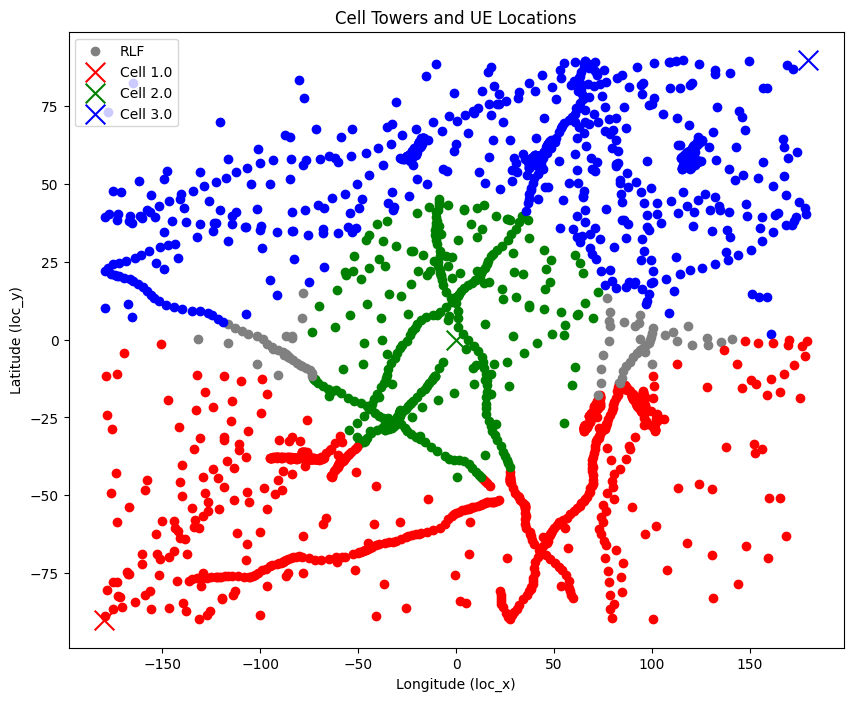

In [ ]:
plot_scatter(predicted, topology)

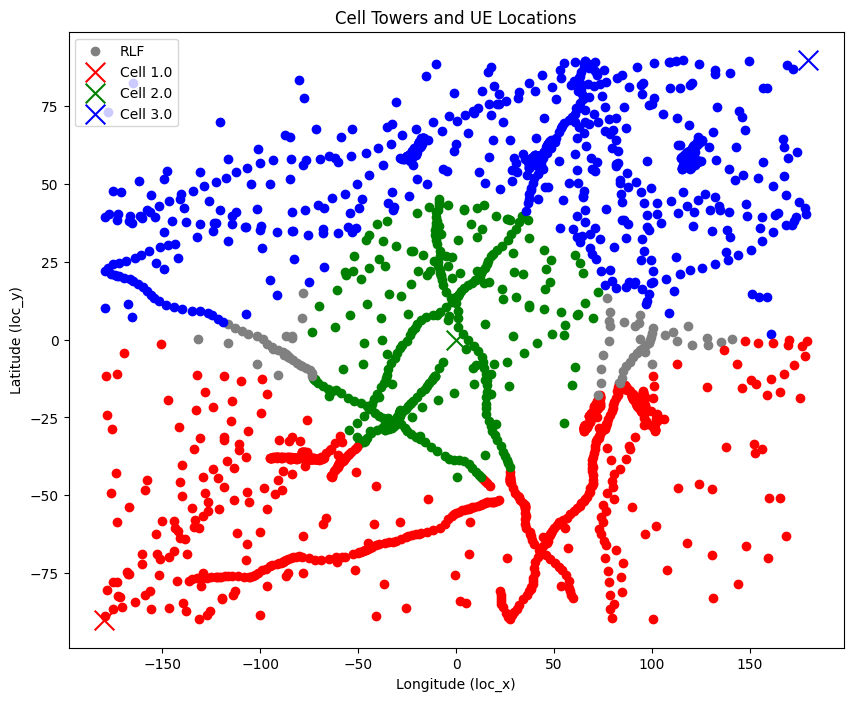

In [ ]:
plot_scatter(online_predicted, topology)

In [ ]:
# compute RSRP as maximum over predicted rx powers
pred_rsrp = np.array(full_prediction_df.pred_means)
# extract true (actual) RSRP from test set
true_rsrp = np.array(full_prediction_df.cell_rxpower_dbm)
# mean absolute error
MAE = abs(true_rsrp - pred_rsrp).mean()
# mean square error
MSE = (abs(true_rsrp - pred_rsrp) ** 2).mean()
# mean absolute percentage error
MAPE = 100 * abs((true_rsrp - pred_rsrp) / true_rsrp).mean()
# 85th percentile error
Percentile85Error = np.percentile(abs(true_rsrp - pred_rsrp), 85)

print("==========")
print(f"MSE = {MSE:0.5f}, MAE = {MAE:0.5f} dB, MAPE = {MAPE:0.5f} %")
print(f"Percentile85Error = {Percentile85Error:0.1f}")
print("==========")

lons = list(full_prediction_df.loc_x)
lats = list(full_prediction_df.loc_y)

MSE = 0.00035, MAE = 0.00931 dB, MAPE = 0.00936 %
Percentile85Error = 0.0


In [ ]:
predicted

,loc_x,loc_y,cell_id,sinr_db,rsrp_dbm
0,-22.625309,59.806764,3.0,-2.379977,-99.439222
1,119.764151,54.857584,3.0,-2.327391,-99.529872
2,72.095437,-20.253892,1.0,-2.879410,-99.914974
3,-67.548009,-38.100941,1.0,-2.681970,-99.750042
4,59.867089,-83.103930,1.0,-1.272097,-98.454312
...,...,...,...,...,...
1995,-48.120062,45.049111,3.0,-2.640651,-99.673974
1996,158.712983,-17.811647,1.0,-2.720702,-99.933732
1997,-51.034072,-42.666303,1.0,-2.664780,-99.697241
1998,-111.870626,-62.077716,1.0,-2.187692,-99.381646


In [ ]:
full_prediction_df.head(10)

,mock_ue_id,loc_x,loc_y,tick,cell_lat,cell_lon,cell_id,cell_az_deg,cell_carrier_freq_mhz,distance_km,cell_rxpower_dbm,relative_bearing,rxpower_dbm,rxpower_stddev_dbm,pred_means
0,0.0,-22.625309,59.806764,0.0,-90.0,-180.0,1.0,0.0,2100.0,16.629500,-100.311970,239.806764,-100.308645,0.267466,-100.308645
1,1.0,119.764151,54.857584,0.0,-90.0,-180.0,1.0,0.0,2100.0,16.595905,-100.294405,234.857584,-100.292561,0.267453,-100.292561
2,2.0,72.095437,-20.253892,0.0,-90.0,-180.0,1.0,0.0,2100.0,15.865016,-99.903196,159.746108,-99.914974,0.267403,-99.914974
3,3.0,-67.548009,-38.100941,0.0,-90.0,-180.0,1.0,0.0,2100.0,15.569455,-99.739854,141.899059,-99.750042,0.267451,-99.750042
4,4.0,59.867089,-83.103930,0.0,-90.0,-180.0,1.0,0.0,2100.0,13.551107,-98.533881,96.896070,-98.454312,0.269040,-98.454312
5,5.0,-10.773668,-11.688919,0.0,-90.0,-180.0,1.0,0.0,2100.0,15.980843,-99.966380,168.311081,-99.977736,0.267391,-99.977736
6,6.0,21.911530,-51.669401,0.0,-90.0,-180.0,1.0,0.0,2100.0,15.266403,-99.569120,128.330599,-99.573714,0.267523,-99.573714
7,7.0,95.432922,-16.541909,0.0,-90.0,-180.0,1.0,0.0,2100.0,15.916869,-99.931539,163.458091,-99.943200,0.267397,-99.943200
8,8.0,48.213793,63.374119,0.0,-90.0,-180.0,1.0,0.0,2100.0,16.653034,-100.324253,243.374119,-100.319811,0.267477,-100.319811
9,9.0,17.242846,-47.208705,0.0,-90.0,-180.0,1.0,0.0,2100.0,15.376489,-99.631529,132.791295,-99.638613,0.267494,-99.638613


## Objective-2

In [ ]:
def reattach_columns(predicted_df, full_prediction_df):
    # Filter full_prediction_df for the needed columns and drop duplicates based on loc_x and loc_y
    filtered_full_df = full_prediction_df[['mock_ue_id', 'tick', 'loc_x', 'loc_y']].drop_duplicates(subset=['loc_x', 'loc_y'])

    # Merge with predicted_df based on loc_x and loc_y, ensuring size matches predicted_df
    merged_df = pd.merge(predicted_df, filtered_full_df, on=['loc_x', 'loc_y'], how='left')

    # Rename mock_ue_id to ue_id
    merged_df.rename(columns={'mock_ue_id': 'ue_id'}, inplace=True)

    return merged_df

In [ ]:
df = reattach_columns(predicted,full_prediction_df)
df

,loc_x,loc_y,cell_id,sinr_db,rsrp_dbm,ue_id,tick
0,-22.625309,59.806764,3.0,-2.379977,-99.439222,0.0,0.0
1,119.764151,54.857584,3.0,-2.327391,-99.529872,1.0,0.0
2,72.095437,-20.253892,1.0,-2.879410,-99.914974,2.0,0.0
3,-67.548009,-38.100941,1.0,-2.681970,-99.750042,3.0,0.0
4,59.867089,-83.103930,1.0,-1.272097,-98.454312,4.0,0.0
...,...,...,...,...,...,...,...
1995,-48.120062,45.049111,3.0,-2.640651,-99.673974,15.0,99.0
1996,158.712983,-17.811647,1.0,-2.720702,-99.933732,16.0,99.0
1997,-51.034072,-42.666303,1.0,-2.664780,-99.697241,17.0,99.0
1998,-111.870626,-62.077716,1.0,-2.187692,-99.381646,18.0,99.0


In [ ]:
def count_handovers(df):
    # Initialize counters for NS and NF handovers
    ns_handover_count = 0
    nf_handover_count = 0
    no_change = 0

    # Define the mapping of cell_id to colors
    color_map = {1: 'red', 2: 'green', 3: 'blue'}
    # Instead of color map we use the cell id and then something to find the RLF
    # Enumeration . Status of the MRO. RLF occurred, HO
    # Track previous color for each UE
    ue_previous_color = {}

    # Loop through the dataframe row by row
    for _, row in df.iterrows():
        ue_id = row['ue_id']
        cell_id = row['cell_id']
        sinr_db = row['sinr_db']

        # Determine current color based on cell_id and sinr_db
        if sinr_db < -2.9:
            current_color = 'grey'  # Radio Link Failure
        else:
            current_color = color_map.get(cell_id, 'black')

        # Check if we have a previous color for this UE
        if ue_id in ue_previous_color:
            previous_color = ue_previous_color[ue_id]

            # Check for successful handovers (NS)
            if current_color!= "grey" and previous_color != current_color:
                ns_handover_count += 1
            # Check for unsuccessful handovers (NF)
            elif current_color == 'grey':
                nf_handover_count += 1
            else:
              no_change += 1


        # Update the previous color for this UE
        ue_previous_color[ue_id] = current_color
    print(ue_previous_color)
    return ns_handover_count, nf_handover_count,no_change

# Example usage:
ns_handover_count, nf_handover_count, no_change = count_handovers(df)
print(f"Number of successful handovers (NS): {ns_handover_count}")
print(f"Number of unsuccessful handovers (NF): {nf_handover_count}")
print(f"No change: {no_change}")




{0.0: 'blue', 1.0: 'blue', 2.0: 'red', 3.0: 'red', 4.0: 'green', 5.0: 'red', 6.0: 'red', 7.0: 'red', 8.0: 'blue', 9.0: 'blue', 10.0: 'grey', 11.0: 'blue', 12.0: 'red', 13.0: 'blue', 14.0: 'red', 15.0: 'blue', 16.0: 'red', 17.0: 'red', 18.0: 'red', 19.0: 'blue'}
Number of successful handovers (NS): 58
Number of unsuccessful handovers (NF): 75
No change: 1847


In [ ]:
# Refined Handover Count Function

def count_handovers(df):
    # Initialize counters for NS (Successful Handovers), NF (Radio Link Failures), and no change
    ns_handover_count = 0
    nf_handover_count = 0
    no_change = 0

    # Threshold for considering a Radio Link Failure (RLF)
    rlf_threshold = -2.9

    # Track the previous state for each UE
    ue_previous_state = {}

    # Loop through the dataframe row by row
    for _, row in df.iterrows():
        ue_id = row['ue_id']
        current_cell_id = row['cell_id']
        current_sinr_db = row['sinr_db']

        # Check if we have previous state for this UE
        if ue_id in ue_previous_state:
            previous_cell_id, previous_sinr_db = ue_previous_state[ue_id]

            # Check for cell ID change
            if previous_cell_id != current_cell_id:
                # Check if the SINR is above the threshold after a cell change
                if current_sinr_db >= rlf_threshold:
                    ns_handover_count += 1  # Successful handover
                else:
                    nf_handover_count += 1  # Failed handover due to RLF after change
            elif previous_sinr_db < rlf_threshold and current_sinr_db >= rlf_threshold:
                ns_handover_count += 1  # Successful recovery from RLF without cell change
            elif current_sinr_db < rlf_threshold:
                nf_handover_count += 1  # Ongoing or new RLF
            else:
                no_change += 1  # No significant event

        else:
            # If first occurrence of UE has SINR below the RLF threshold, consider it as RLF
            if current_sinr_db < rlf_threshold:
                nf_handover_count += 1
            else:
                no_change += 1  # No significant event when UE first appears and SINR is above threshold

        # Update the state for this UE
        ue_previous_state[ue_id] = (current_cell_id, current_sinr_db)

    return ns_handover_count, nf_handover_count, no_change




ns_handover_count, nf_handover_count, no_change = count_handovers(df)
print(f"Number of successful handovers (NS): {ns_handover_count}")
print(f"Number of unsuccessful handovers (NF): {nf_handover_count}")
print(f"No change: {no_change}")

Number of successful handovers (NS): 58
Number of unsuccessful handovers (NF): 75
No change: 1867


In [ ]:
def calculate_mro_metric(ns_handover_count, nf_handover_count, prediction_ue_data):
    # Constants for interruption times
    ts = 50 / 1000  # Convert ms to seconds
    t_nas = 1000 / 1000  # Convert ms to seconds

    # Calculate total time (T) based on ticks; assuming each tick represents a uniform time slice
    # This could be adjusted if ticks represent variable time slices
    # Rather than passing the UE Data as whole we can send just an integar for tick
    ticks = len(prediction_ue_data['tick'].unique())
    # Assuming each tick represents 50ms (this value may need to be adjusted based on actual data characteristics)
    tick_duration_seconds = 1  # 1 second per tick
    T = ticks * tick_duration_seconds

    # Calculate D
    D = T - (ns_handover_count * ts + nf_handover_count * t_nas)

    return D


In [ ]:
D = calculate_mro_metric(ns_handover_count, nf_handover_count, prediction_ue_data)
print(f"Penalty D: {D}")

Penalty D: 22.099999999999994


## Objective 3

In [ ]:
def calculate_mro_metric_with_window(prediction_ue_data, window_size=20, stride=10):
    # Constants for interruption times in seconds
    ts = 50 / 1000  # 50 ms
    t_nas = 1000 / 1000  # 1000 ms

    # Initialize a list to hold penalties for each window
    penalties = []

    # Get unique ticks and sort them
    ticks = sorted(prediction_ue_data['tick'].unique())

    # Process each window
    for start_index in range(0, len(ticks) - window_size + 1, stride):
        # Window slice based on ticks
        end_index = start_index + window_size
        window_ticks = ticks[start_index:end_index]

        # Filter data for the current window
        window_data = prediction_ue_data[prediction_ue_data['tick'].isin(window_ticks)]

        # Calculate handovers within this window
        ns_handover_count, nf_handover_count, _ = count_handovers(window_data)

        # Total time for the window
        T = len(window_ticks)  # Assuming each tick represents 1 second

        # Calculate penalty for the current window
        D = T - (ns_handover_count * ts + nf_handover_count * t_nas)
        penalties.append(D)

    # Return a list of penalties for each window
    return penalties


[28.9, 27.9, 27.799999999999997, 27.799999999999997, 27.85, 27.9, 27.950000000000003, 27.0, 26.0, 23.950000000000003, 21.950000000000003, 19.950000000000003, 17.9, 15.899999999999999, 13.899999999999999, 12.799999999999997, 11.799999999999997, 9.850000000000001, 7.950000000000003, 5.950000000000003, 5.900000000000006, 4.900000000000006, 3.799999999999997, 2.799999999999997, 1.7999999999999972, -0.20000000000000284, -1.2000000000000028, -1.2000000000000028, -2.200000000000003, -3.200000000000003, -3.1500000000000057]


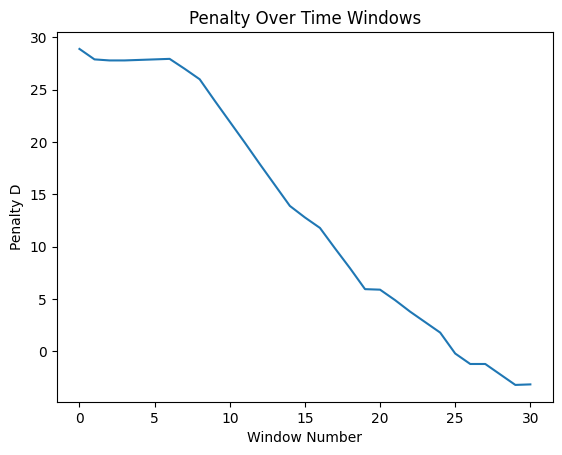

In [ ]:
penalties = calculate_mro_metric_with_window(df, window_size=70, stride=1)
print(penalties)
# Plotting penalties
import matplotlib.pyplot as plt

window_numbers = range(len(penalties))
plt.plot(window_numbers, penalties)
plt.xlabel('Window Number')
plt.ylabel('Penalty D')
plt.title('Penalty Over Time Windows')
plt.show()


### preprocessed_prediction_ue_data

Note: typo in 'preprocessed'

In [ ]:
preproceseed_prediction_ue_data.head()

,mock_ue_id,loc_x,loc_y,tick,cell_lat,cell_lon,cell_id,cell_az_deg,cell_carrier_freq_mhz,distance_km,cell_rxpower_dbm,relative_bearing
0,0.0,-22.625309,59.806764,0.0,-90.0,-180.0,1.0,0.0,2100.0,16.629500,-100.311970,239.806764
1,0.0,-22.625309,59.806764,0.0,0.0,0.0,2.0,120.0,2100.0,15.752768,-99.841523,266.698642
2,0.0,-22.625309,59.806764,0.0,90.0,180.0,3.0,240.0,2100.0,15.027772,-99.432278,60.193236
3,1.0,119.764151,54.857584,0.0,-90.0,-180.0,1.0,0.0,2100.0,16.595905,-100.294405,234.857584
4,1.0,119.764151,54.857584,0.0,0.0,0.0,2.0,120.0,2100.0,16.289273,-100.132420,269.925194


In [ ]:
from google.colab import files

# uncomment below to download

# preproceseed_prediction_ue_data.to_csv('preproceseed_prediction_ue_data.csv', index=False)
# files.download('preproceseed_prediction_ue_data.csv')

## Objective 4

In [ ]:
analysis_df = preproceseed_prediction_ue_data.copy()

# Calculate the difference between consecutive cell_rxpower_dbm values in the new DataFrame
analysis_df['rxpower_diff'] = analysis_df['cell_rxpower_dbm'].diff()

# Calculate overall statistics of the differences
statistics = {
    'average_difference': analysis_df['rxpower_diff'].mean(),
    'max_difference': analysis_df['rxpower_diff'].max(),
    'min_difference': analysis_df['rxpower_diff'].min(),
    'std_difference': analysis_df['rxpower_diff'].std()
}

print("Overall Statistics:")
print(f"Average difference: {statistics['average_difference']:.4f} dBm")
print(f"Maximum difference: {statistics['max_difference']:.4f} dBm")
print(f"Minimum difference: {statistics['min_difference']:.4f} dBm")
print(f"Standard deviation: {statistics['std_difference']:.4f} dBm")


Overall Statistics:
Average difference: 0.0001 dBm
Maximum difference: 4.2727 dBm
Minimum difference: -4.4798 dBm
Standard deviation: 0.6362 dBm


In [ ]:
tick_dataframes = {}

# Group the data by tick
for tick in sorted(preproceseed_prediction_ue_data['tick'].unique()):
    tick_dataframes[tick] = preproceseed_prediction_ue_data[preproceseed_prediction_ue_data['tick'] == tick].copy()

### Checkpoint

> prerequisits: add the preproceseed_prediction_ue_data.csv to your `/content/drive/MyDrive/Maveric/Data/MRO/preproceseed_prediction_ue_data.csv`

- can run from this poin onwards without running previous cells.

In [79]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [116]:
preproceseed_prediction_ue_data = pd.read_csv('/content/drive/MyDrive/Maveric/Data/MRO/preproceseed_prediction_ue_data.csv')
print(preproceseed_prediction_ue_data.shape)

preproceseed_prediction_ue_data.head(10)

(6000, 12)


,mock_ue_id,loc_x,loc_y,tick,cell_lat,cell_lon,cell_id,cell_az_deg,cell_carrier_freq_mhz,distance_km,cell_rxpower_dbm,relative_bearing
0,0.0,-22.625309,59.806764,0.0,-90.0,-180.0,1.0,0.0,2100.0,16.629500,-100.311970,239.806764
1,0.0,-22.625309,59.806764,0.0,0.0,0.0,2.0,120.0,2100.0,15.752768,-99.841523,266.698642
2,0.0,-22.625309,59.806764,0.0,90.0,180.0,3.0,240.0,2100.0,15.027772,-99.432278,60.193236
3,1.0,119.764151,54.857584,0.0,-90.0,-180.0,1.0,0.0,2100.0,16.595905,-100.294405,234.857584
4,1.0,119.764151,54.857584,0.0,0.0,0.0,2.0,120.0,2100.0,16.289273,-100.132420,269.925194
5,1.0,119.764151,54.857584,0.0,90.0,180.0,3.0,240.0,2100.0,15.179563,-99.519571,65.142416
6,2.0,72.095437,-20.253892,0.0,-90.0,-180.0,1.0,0.0,2100.0,15.865016,-99.903196,159.746108
7,2.0,72.095437,-20.253892,0.0,0.0,0.0,2.0,120.0,2100.0,15.913847,-99.929889,103.172748
8,2.0,72.095437,-20.253892,0.0,90.0,180.0,3.0,240.0,2100.0,16.322940,-100.150353,140.253892
9,3.0,-67.548009,-38.100941,0.0,-90.0,-180.0,1.0,0.0,2100.0,15.569455,-99.739854,141.899059


### add_sinr_column()
As per Lawanya's directions

In [157]:
import numpy as np
import pandas as pd

LATENT_BACKGROUND_NOISE_DB = -150  # from constants

def add_sinr_column(df: pd.DataFrame) -> pd.DataFrame:
    # Function to compute SINR for a group of rows corresponding to one frequency layer.
    def compute_layer_sinr(group: pd.DataFrame) -> float:
        # Get the RSRP: the highest received power in this frequency group for the specific tick.
        serving_row = group.loc[group['cell_rxpower_dbm'].idxmax()]
        serving_rsrp_dbm = serving_row['cell_rxpower_dbm']

        # Convert background noise from dB to linear scale.
        noise_linear = 10 ** (LATENT_BACKGROUND_NOISE_DB / 10)

        # Convert all received powers from dBm to linear scale and sum only those on the same frequency.
        interference_power_linear = np.sum(10 ** (group['cell_rxpower_dbm'] / 10))

        # Exclude the serving cell's power from interference
        serving_power_linear = 10 ** (serving_rsrp_dbm / 10)
        interference_linear = interference_power_linear - serving_power_linear

        # Convert total interference plus noise back to dB
        total_interference_noise_dbm = 10 * np.log10(interference_linear + noise_linear)

        # SINR is the difference between serving RSRP and total interference-plus-noise (both in dBm)
        sinr_db = serving_rsrp_dbm - total_interference_noise_dbm

        return sinr_db

    # This dictionary will store the computed SINR per (UE id, tick, frequency).
    ue_sinr = {}

    # Group by mock_ue_id, tick, and frequency to compute SINR separately per frequency.
    for (ue_id, tick, freq), ue_tick_freq_group in df.groupby(["mock_ue_id", "tick", "cell_carrier_freq_mhz"]):
        ue_sinr[(ue_id, tick, freq)] = compute_layer_sinr(ue_tick_freq_group)

    # Map the computed SINR back to the original dataframe rows.
    df = df.copy()
    df["sinr_db"] = df.apply(lambda row: ue_sinr.get((row["mock_ue_id"], row["tick"], row["cell_carrier_freq_mhz"]), np.nan), axis=1)

    return df


In [120]:
preproceseed_prediction_ue_data = add_sinr_column(preproceseed_prediction_ue_data)
preproceseed_prediction_ue_data

,mock_ue_id,loc_x,loc_y,tick,cell_lat,cell_lon,cell_id,cell_az_deg,cell_carrier_freq_mhz,distance_km,cell_rxpower_dbm,relative_bearing,sinr_db
0,0.0,-22.625309,59.806764,0.0,-90.0,-180.0,1.0,0.0,2100.0,16.629500,-100.311970,239.806764,-2.372220
1,0.0,-22.625309,59.806764,0.0,0.0,0.0,2.0,120.0,2100.0,15.752768,-99.841523,266.698642,-2.372220
2,0.0,-22.625309,59.806764,0.0,90.0,180.0,3.0,240.0,2100.0,15.027772,-99.432278,60.193236,-2.372220
3,1.0,119.764151,54.857584,0.0,-90.0,-180.0,1.0,0.0,2100.0,16.595905,-100.294405,234.857584,-2.317237
4,1.0,119.764151,54.857584,0.0,0.0,0.0,2.0,120.0,2100.0,16.289273,-100.132420,269.925194,-2.317237
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,18.0,-111.870626,-62.077716,99.0,0.0,0.0,2.0,120.0,2100.0,16.225783,-100.098499,85.092448,-2.189536
5996,18.0,-111.870626,-62.077716,99.0,90.0,180.0,3.0,240.0,2100.0,16.644546,-100.319825,182.077716,-2.189536
5997,19.0,130.007484,41.546845,99.0,-90.0,-180.0,1.0,0.0,2100.0,16.499517,-100.243810,221.546845,-2.495036
5998,19.0,130.007484,41.546845,99.0,0.0,0.0,2.0,120.0,2100.0,16.397261,-100.189812,276.811685,-2.495036


### _update_current_strongest()

In [94]:
import pandas as pd

def _update_current_strongest(ue_data_for_current_tick, past_attachment, hyst):
    """
    Function to update UE data based on hysteresis condition and past attachment.
    It selects the best data between current tick and past attachment for each mock_ue_id.
    """
    # Merge the current tick data with past attachment data (to compare past power)
    merged_df = pd.merge(ue_data_for_current_tick, past_attachment,
                         on='mock_ue_id', how='left', suffixes=('', '_past'))

    # Initialize an empty list to store the final rows
    final_data = []

    # Group by 'mock_ue_id' to process each UE individually
    for mock_ue_id, group in merged_df.groupby('mock_ue_id'):
        # Initialize variables to track the best row for the mock_ue_id
        best_row = None
        best_power = -999  # Start with an arbitrarily low value for comparison (can also use NaN)

        # Iterate through each row (cell_id) for the current mock_ue_id
        for _, row in group.iterrows():
            current_power = row['sinr_db']
            past_cell_id = row['cell_id_past']  # Cell ID from past attachment

            # Retrieve the past data for the previous cell_id of this mock_ue_id
            past_data = ue_data_for_current_tick[(ue_data_for_current_tick['mock_ue_id'] == mock_ue_id) &
                                                 (ue_data_for_current_tick['cell_id'] == past_cell_id)]

            # If past data exists, get the past power
            if not past_data.empty:
                past_power = past_data.iloc[0]['sinr_db']
            else:
                past_power = -999  # Default value if no past data found

            # Check if the current power exceeds the past power by at least 'hyst'
            if current_power - past_power >= hyst:
                # If the condition is met, consider the current row (i.e., current power is better)
                if current_power > best_power:  # Keep the row with the highest power
                    best_row = row
                    best_power = current_power
            else:
                # Otherwise, consider the past data (if it has higher power)
                if past_power > best_power:
                    best_row = past_data.iloc[0]  # Select the past data row
                    best_power = past_power

        # After processing all cell_ids for this mock_ue_id, add the best row to the final list
        if best_row is not None:
            final_data.append(best_row)

    # Convert the final list of rows into a DataFrame
    final_df = pd.DataFrame(final_data)

    # Remove columns that have the '_past' suffix (since we only need current data)
    final_df = final_df.loc[:, ~final_df.columns.str.endswith('_past')]

    return final_df


In [ ]:
# Dummy Example

# Dummy input data for ue_data_for_current_tick
input_per_tick = pd.DataFrame({
    'mock_ue_id': [1, 1, 2, 2, 3, 3],
    'cell_id':    [1, 2, 1, 2, 1, 2],
    'cell_rxpower_dbm': [-80, -75, -90, -85, -95, -92]
})
past_data = pd.DataFrame({
    'mock_ue_id':   [1, 2, 3],
    'cell_id_past': [2, 1, 2],  # Past cell_id each UE was attached to
    'cell_rxpower_dbm_past': [-78, -88, -93]  # Past received power levels
})

# if everything went right ue_id 2 should switch if hyst == 5
hyst = 5
result = _update_current_strongest(input_per_tick, past_data, hyst)
print(result)

   mock_ue_id  cell_id  cell_rxpower_dbm
1         1.0      2.0             -75.0
3         2.0      2.0             -85.0
5         3.0      2.0             -92.0


### _update_current_attachement()

In [95]:
def _update_current_attachement(strongest_server_history, ue_data_for_current_tick, past_attachment): # TODO: FUTURE FIX --> all 'attachment' typos
  current_attachment_list = [] # contains updated ue -> cell + current data
  merged_df = pd.concat(strongest_server_history, ignore_index=True)

  #individual UE scope
  for UE in ue_data_for_current_tick['mock_ue_id'].unique():
    # Check consistency for this specific UE
    history_consistency_check = merged_df[merged_df['mock_ue_id'] == UE]['cell_id'].nunique()
    consistent_cell_id = merged_df[merged_df['mock_ue_id'] == UE]['cell_id'].unique()[0]

    # attach consistent cell or past cell decision
    if history_consistency_check == 1:
      current_attachment_list.append(ue_data_for_current_tick[(ue_data_for_current_tick['mock_ue_id'] == UE) & (ue_data_for_current_tick['cell_id'] == consistent_cell_id)].iloc[0])
    else:
      past_cell_id = past_attachment[past_attachment['mock_ue_id'] == UE]['cell_id'].values[0]
      current_attachment_list.append(ue_data_for_current_tick[(ue_data_for_current_tick['mock_ue_id'] == UE) & (ue_data_for_current_tick['cell_id'] == past_cell_id)].iloc[0])

  current_attachment = pd.DataFrame(current_attachment_list).reset_index(drop=True)
  # current_attachement = _check_hyst_in_current_tick(ue_data_for_current_tick, current_attachment, past_attachment, hyst) # TODO: FUTURE FIX --> all 'attachment' typos

  return current_attachment


In [ ]:
# Example --> _update_current_attachment()

import pandas as pd

# consider 3 UEs and 2 cells

TTT = 3
hyst = 5

# past_attachment: pd.DataFrame --> output of _update_current_attachment() from last tick, last attached cells
past_attachment = pd.DataFrame({
    'mock_ue_id':       [1, 2, 3],
    'cell_id':          [2, 2, 1],
    'cell_rxpower_dbm': [70, 75, 90]
})

df1 = pd.DataFrame({
    'mock_ue_id':       [1, 2, 3],
    'cell_id':          [1, 1, 2],
    'cell_rxpower_dbm': [80, 75, 90]
})

df2 = pd.DataFrame({
    'mock_ue_id':       [1, 2, 3],
    'cell_id':          [2, 1, 2],
    'cell_rxpower_dbm': [75, 76, 100]
})

# strongest_server_history: List[pd.DataFrame] --> strongest cell for previous TTT-1 ticks
strongest_server_history = [df1, df2] # len is TTT-1 = 3-1 = 2

# ue_data_for_current_tick: pd.DataFrame --> contains calculated rx_power for UEs x cells
ue_data_for_current_tick = pd.DataFrame({
    'mock_ue_id':       [1, 1, 2, 2, 3, 3],
    'cell_id':          [1, 2, 1, 2, 1, 2],
    'cell_rxpower_dbm': [68, 76, 40, 74, 91, 102]
})

current_attachment = _update_current_attachement(strongest_server_history, ue_data_for_current_tick, past_attachment)

print('past attachment:')
print(past_attachment, end='\n\n')
print('current attachment:')
print(current_attachment, end='\n\n')
print('ue data for current tick:')
print(ue_data_for_current_tick)

# ue 1 didn't switch attachment
# ue 2 switched attachment
# ue 3 switched attachment

past attachment:
   mock_ue_id  cell_id  cell_rxpower_dbm
0           1        2                70
1           2        2                75
2           3        1                90

current attachment:
   mock_ue_id  cell_id  cell_rxpower_dbm
0           1        2                76
1           2        1                40
2           3        2               102

ue data for current tick:
   mock_ue_id  cell_id  cell_rxpower_dbm
0           1        1                68
1           1        2                76
2           2        1                40
3           2        2                74
4           3        1                91
5           3        2               102


### _check_hyst_in_current_tick()

In [96]:
def _check_hyst_in_current_tick(ue_data_for_current_tick: pd.DataFrame, current_attachement: pd.DataFrame, past_attachment: pd.DataFrame, hyst: float) -> pd.DataFrame:
    # * Check data consistency
    if current_attachement.shape != past_attachment.shape or set(current_attachement['mock_ue_id']) != set(past_attachment['mock_ue_id']) or set(current_attachement['cell_id']) != set(past_attachment['cell_id']):
        raise AssertionError('current attachment and past attachment are not consistent. Check their shape, mock_ue_id and cell_id columns.')

    # * current attached cell scope
    for i, curr in current_attachement.iterrows():
        prev = past_attachment[past_attachment['mock_ue_id'] == curr['mock_ue_id']].iloc[0]

        # * ignoring if no cell switch for this UE
        if curr['cell_id'] == prev['cell_id']:
            continue

        # * get rxpowers for current and previous attached cell calculated in current tick
        curr_attachment_rxpower = ue_data_for_current_tick[(ue_data_for_current_tick['mock_ue_id'] == curr['mock_ue_id']) & (ue_data_for_current_tick['cell_id'] == curr['cell_id'])]['sinr_db'].values[0]
        prev_attachment_rxpower = ue_data_for_current_tick[(ue_data_for_current_tick['mock_ue_id'] == prev['mock_ue_id']) & (ue_data_for_current_tick['cell_id'] == prev['cell_id'])]['sinr_db'].values[0]

        # * hysteresis check & revert if failed
        if curr_attachment_rxpower < prev_attachment_rxpower + hyst:
            current_attachement.at[i, 'cell_id'] = prev['cell_id']
            current_attachement.at[i, 'sinr_db'] = prev_attachment_rxpower

    return current_attachement

In [ ]:
# Example --> _check_hyst_in_current_tick()

import pandas as pd

# consider 3 UEs and 2 cells

TTT = 3
hyst = 5

# past_attachment: pd.DataFrame --> output of _update_current_attachment() from last tick, last attached cells
past_attachment = pd.DataFrame({
    'mock_ue_id':       [1, 2, 3],
    'cell_id':          [2, 2, 1],
    'cell_rxpower_dbm': [70, 75, 90]
})

# ue_data_for_current_tick: pd.DataFrame --> contains calculated rx_power for UEs x cells
ue_data_for_current_tick = pd.DataFrame({
    'mock_ue_id':       [1, 1, 2, 2, 3, 3],
    'cell_id':          [1, 2, 1, 2, 1, 2],
    'cell_rxpower_dbm': [68, 76, 40, 74, 91, 102]
})

# this df is calculated inside _update_current_attachment()
current_attachment = pd.DataFrame({
    "mock_ue_id": [1, 2, 3],
    "cell_id": [2, 1, 2],
    "cell_rxpower_dbm": [76, 40, 102]
})

# as (mock_ue_id, cell_id) = (2, 1) connects to 40 dbm which doesn't satisfy hyst
# as previous connection (2, 2) offers 74 dbm, so revert.
current_attachement = _check_hyst_in_current_tick(ue_data_for_current_tick, current_attachment, past_attachment, hyst)
current_attachement

,mock_ue_id,cell_id,cell_rxpower_dbm
0,1,2,76
1,2,2,74
2,3,2,102


### perform_attachment_hyst_ttt_per_tick()

In [97]:
def perform_attachment_hyst_ttt_per_tick(ue_data_for_current_tick, strongest_server_history, past_attachement, ttt, hyst, use_strongest_server = False):
  current_strongest = ue_data_for_current_tick.loc[ue_data_for_current_tick.groupby('mock_ue_id')['sinr_db'].idxmax()]
  if len(strongest_server_history) >= ttt:
    raise AssertionError("Error: Strongest_Server_History needs to be Less Than TTT!")
  else:
    if use_strongest_server:
      current_attachement = current_strongest
      strongest_server_history.append(current_strongest)

    else:
      if ttt == len(strongest_server_history) + 1:
        current_strongest = _update_current_strongest(ue_data_for_current_tick, past_attachement, hyst)
        strongest_server_history.append(current_strongest)
        current_attachement = _update_current_attachement(strongest_server_history, ue_data_for_current_tick, past_attachement)
        current_attachement = _check_hyst_in_current_tick(ue_data_for_current_tick, current_attachement, past_attachement, hyst) # TODO: FUTURE FIX --> all 'attachment' typos
      else:
        raise AssertionError("Length of Strongest Server History must be EQUALS to TTT - 1.\n Call Perform Attachment with use_strongest_server = True")


  if len(strongest_server_history) == ttt:
    strongest_server_history.pop(0)

  # FIX ME : SINR_DB
  return strongest_server_history, current_attachement

### Looped Perform Attachment Per Tick




In [98]:
strongest_server_hystory= []
current_attachement = pd.DataFrame()
ttt = 2
hyst = 0.0001

In [99]:
tick_dataframes = {}

# Group the data by tick
for tick in sorted(preproceseed_prediction_ue_data['tick'].unique()):
    tick_dataframes[tick] = preproceseed_prediction_ue_data[preproceseed_prediction_ue_data['tick'] == tick].copy()

In [100]:
cell_attached_df = pd.DataFrame()

In [101]:
for tick in range(len(tick_dataframes)):
  if ttt -1 > len(strongest_server_hystory):
    strongest_server_history, current_attachement = perform_attachment_hyst_ttt_per_tick(tick_dataframes[tick],strongest_server_hystory,current_attachement,ttt,hyst,use_strongest_server = True)
  else:
    strongest_server_history, current_attachement = perform_attachment_hyst_ttt_per_tick(tick_dataframes[tick],strongest_server_hystory,current_attachement,ttt,hyst,use_strongest_server = False)
  cell_attached_df = pd.concat([cell_attached_df,current_attachement])

In [102]:
cell_attached_df

,mock_ue_id,loc_x,loc_y,tick,cell_lat,cell_lon,cell_id,cell_az_deg,cell_carrier_freq_mhz,distance_km,cell_rxpower_dbm,relative_bearing,sinr_db
0,0.0,-22.625309,59.806764,0.0,-90.0,-180.0,1.0,0.0,2100.0,16.629500,-100.311970,239.806764,-24.237940
3,1.0,119.764151,54.857584,0.0,-90.0,-180.0,1.0,0.0,2100.0,16.595905,-100.294405,234.857584,-24.157580
6,2.0,72.095437,-20.253892,0.0,-90.0,-180.0,1.0,0.0,2100.0,15.865016,-99.903196,159.746108,-24.598625
9,3.0,-67.548009,-38.100941,0.0,-90.0,-180.0,1.0,0.0,2100.0,15.569455,-99.739854,141.899059,-24.507043
12,4.0,59.867089,-83.103930,0.0,-90.0,-180.0,1.0,0.0,2100.0,13.551107,-98.533881,96.896070,-23.169864
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15,15.0,-48.120062,45.049111,99.0,-90.0,-180.0,1.0,0.0,2100.0,16.525792,-100.257632,225.049111,-23.984047
16,16.0,158.712983,-17.811647,99.0,-90.0,-180.0,1.0,0.0,2100.0,15.899433,-99.922018,162.188353,-22.026299
17,17.0,-51.034072,-42.666303,99.0,-90.0,-180.0,1.0,0.0,2100.0,15.477376,-99.688333,137.333697,-22.253895
18,18.0,-111.870626,-62.077716,99.0,-90.0,-180.0,1.0,0.0,2100.0,14.949579,-99.386965,117.922284,-21.552189


### Automated Perform Attachment for Hyst & TTT

In [103]:
def perform_attachment_hyst_ttt(ue_data, hyst, ttt):
  strongest_server_hystory= []
  current_attachement = pd.DataFrame()

  tick_dataframes = {}
  # Group the data by tick
  for tick in sorted(ue_data['tick'].unique()):
      tick_dataframes[tick] = ue_data[ue_data['tick'] == tick].copy()

  cell_attached_df = pd.DataFrame()
  for tick in range(len(tick_dataframes)):
    if ttt - 1 > len(strongest_server_hystory):
      strongest_server_history, current_attachement = perform_attachment_hyst_ttt_per_tick(tick_dataframes[tick],strongest_server_hystory,current_attachement,ttt,hyst,use_strongest_server = True)
    else:
      strongest_server_history, current_attachement = perform_attachment_hyst_ttt_per_tick(tick_dataframes[tick],strongest_server_hystory,current_attachement,ttt,hyst,use_strongest_server = False)
    cell_attached_df = pd.concat([cell_attached_df,current_attachement])

  return cell_attached_df


### HYST & TTT

In [121]:
final_df = perform_attachment_hyst_ttt(preproceseed_prediction_ue_data,hyst=.5,ttt=5)

In [122]:
final_df[final_df['mock_ue_id'] == 0]

,mock_ue_id,loc_x,loc_y,tick,cell_lat,cell_lon,cell_id,cell_az_deg,cell_carrier_freq_mhz,distance_km,cell_rxpower_dbm,relative_bearing,sinr_db
0,0.0,-22.625309,59.806764,0.0,-90.0,-180.0,1.0,0.0,2100.0,16.629500,-100.311970,239.806764,-2.372220
60,0.0,-22.737059,59.710280,1.0,-90.0,-180.0,1.0,0.0,2100.0,16.628856,-100.311633,239.710280,-2.374514
120,0.0,-24.118149,59.217986,2.0,-90.0,-180.0,1.0,0.0,2100.0,16.625562,-100.309913,239.217986,-2.385220
180,0.0,-24.963620,58.869448,3.0,-90.0,-180.0,1.0,0.0,2100.0,16.623224,-100.308691,238.869448,-2.392778
0,0.0,-25.384123,58.623009,4.0,-90.0,-180.0,1.0,0.0,2100.0,16.621567,-100.307825,238.623009,-2.398255
...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,0.0,-22.315053,59.352003,95.0,-90.0,-180.0,1.0,0.0,2100.0,16.626460,-100.310382,239.352003,-2.383845
0,0.0,-21.925920,59.442134,96.0,-90.0,-180.0,1.0,0.0,2100.0,16.627063,-100.310697,239.442134,-2.382010
0,0.0,-21.704894,59.498016,97.0,-90.0,-180.0,1.0,0.0,2100.0,16.627437,-100.310892,239.498016,-2.380845
0,0.0,-22.036717,59.385696,98.0,-90.0,-180.0,1.0,0.0,2100.0,16.626685,-100.310499,239.385696,-2.383297


In [ ]:
#preproceseed_prediction_ue_data.to_csv('initial_full_data.csv')

In [123]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

def plot_rxpower_over_time(df: pd.DataFrame, ue_id: int):
    """
    Plots cell_rxpower_dbm over tick for a specific mock_ue_id with line color changing based on cell_id.

    Parameters:
    df (pd.DataFrame): Input dataframe containing the necessary columns.
    ue_id (int): The mock_ue_id to filter the dataframe by.
    """
    # Filter DataFrame for the specified ue_id
    df_filtered = df[df['mock_ue_id'] == ue_id].sort_values(by='tick')

    if df_filtered.empty:
        print(f"No data found for mock_ue_id {ue_id}.")
        return

    # Get unique cell_ids and assign a color to each
    unique_cells = df_filtered['cell_id'].unique()
    colors = sns.color_palette("husl", len(unique_cells))  # Use seaborn color palette
    cell_color_map = {cell: colors[i] for i, cell in enumerate(unique_cells)}

    # Plot the data with color changing based on cell_id
    plt.figure(figsize=(12, 6))
    prev_cell = None
    for i in range(len(df_filtered) - 1):
        row1, row2 = df_filtered.iloc[i], df_filtered.iloc[i + 1]
        color = cell_color_map[row1['cell_id']]
        plt.plot([row1['tick'], row2['tick']], [row1['sinr_db'], row2['sinr_db']],
                 color=color, linewidth=2)

    # Labels and title
    plt.xlabel("Tick (Time)")
    plt.ylabel("Cell RX Power (dBm)")
    plt.title(f"Cell RX Power over Time for mock_ue_id {ue_id}")

    # Legend
    legend_labels = [plt.Line2D([0], [0], color=color, lw=2, label=f"Cell {cell}") for cell, color in cell_color_map.items()]
    plt.legend(handles=legend_labels, title="Cell ID")

    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

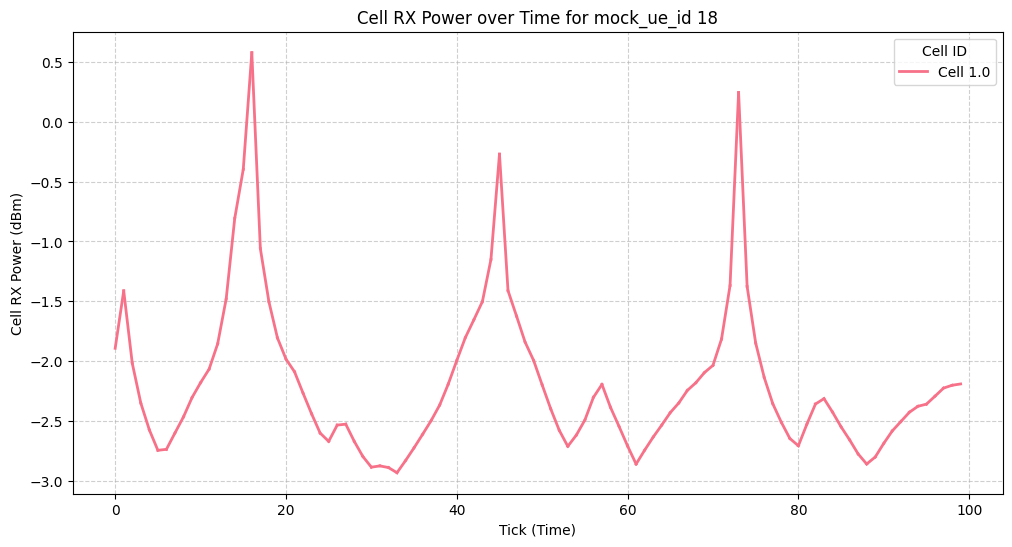

In [124]:
plot_rxpower_over_time(final_df,18)

In [125]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

def total_plot_rxpower_over_time(df: pd.DataFrame, total_ue: pd.DataFrame, ue_id: int):
    """
    Plots cell_rxpower_dbm over tick for a specific mock_ue_id with line color changing based on cell_id.
    Also overlays the data for the given ue_id using a green dotted line.

    Parameters:
    df (pd.DataFrame): Input dataframe containing the necessary columns for the selected UE.
    total_ue (pd.DataFrame): Dataframe containing all UE data for plotting cell power over time.
    ue_id (int): The mock_ue_id to filter the dataframe by.
    """
    # Filter DataFrames
    df_filtered = df[df['mock_ue_id'] == ue_id].sort_values(by='tick')
    total_filtered = total_ue[total_ue['mock_ue_id'] == ue_id].sort_values(by='tick')

    if df_filtered.empty or total_filtered.empty:
        print(f"No data found for mock_ue_id {ue_id}.")
        return

    # Assign colors for total_ue dataset
    unique_cells_total = total_filtered['cell_id'].unique()
    colors_total = sns.color_palette("husl", len(unique_cells_total))
    cell_color_map_total = {cell: colors_total[i] for i, cell in enumerate(unique_cells_total)}

    # Plot the total_ue dataset
    plt.figure(figsize=(12, 6))
    for cell in unique_cells_total:
        cell_data = total_filtered[total_filtered['cell_id'] == cell]
        plt.plot(cell_data['tick'], cell_data['sinr_db'], label=f"Cell {cell}",
                 color=cell_color_map_total[cell], linewidth=2)

    # Overlay the selected df with a green dotted line
    plt.plot(df_filtered['tick'], df_filtered['sinr_db'], linestyle='dotted', color='black', linewidth=2, label=f"Connected To Cell")

    # Labels and title
    plt.xlabel("Tick (Time)")
    plt.ylabel("Sinr_DB")
    plt.title(f"Sinr_DB over Time for UE: {ue_id}")

    # Legend
    plt.legend(title="Cell ID")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Example usage:
# df = pd.read_csv("your_data.csv")
# total_ue = pd.read_csv("total_ue_data.csv")
# plot_rxpower_over_time(df, total_ue, ue_id=1)


In [ ]:
final_df.to_csv('connected_df.csv')

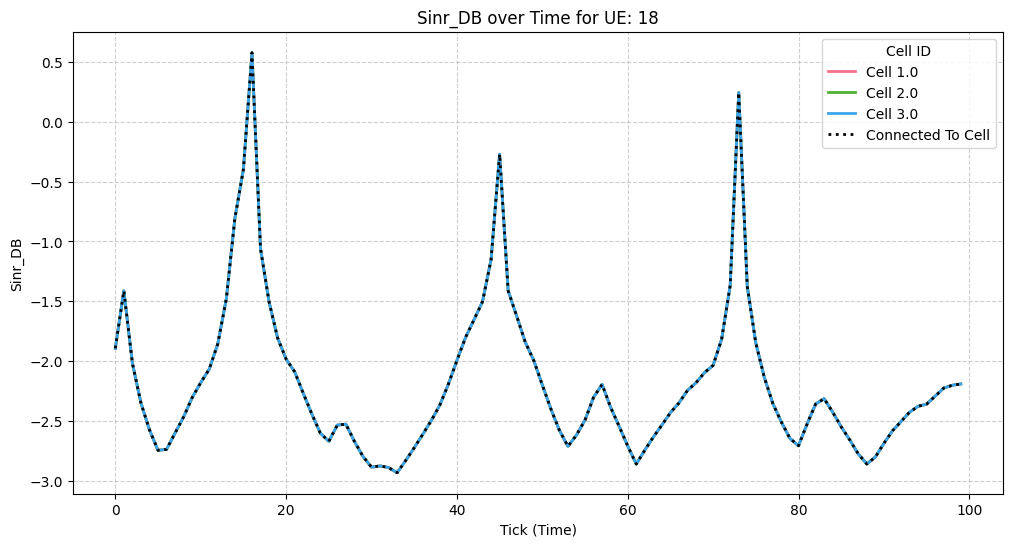

In [127]:
total_plot_rxpower_over_time(final_df, preproceseed_prediction_ue_data, 18)

### New simulation with diff frequency

In [158]:
preproceseed_prediction_ue_data = pd.read_csv('/content/drive/MyDrive/Maveric/Data/MRO/preproceseed_prediction_ue_data.csv')

In [159]:
freq_mapping = {1: 2400, 2: 2400, 3: 1900}  # Assign specific frequencies to cells
starting_df = preproceseed_prediction_ue_data.copy()
starting_df['cell_carrier_freq_mhz'] = starting_df['cell_id'].map(freq_mapping)

In [160]:
starting_df.head()

,mock_ue_id,loc_x,loc_y,tick,cell_lat,cell_lon,cell_id,cell_az_deg,cell_carrier_freq_mhz,distance_km,cell_rxpower_dbm,relative_bearing
0,0.0,-22.625309,59.806764,0.0,-90.0,-180.0,1.0,0.0,2400,16.629500,-100.311970,239.806764
1,0.0,-22.625309,59.806764,0.0,0.0,0.0,2.0,120.0,2400,15.752768,-99.841523,266.698642
2,0.0,-22.625309,59.806764,0.0,90.0,180.0,3.0,240.0,1900,15.027772,-99.432278,60.193236
3,1.0,119.764151,54.857584,0.0,-90.0,-180.0,1.0,0.0,2400,16.595905,-100.294405,234.857584
4,1.0,119.764151,54.857584,0.0,0.0,0.0,2.0,120.0,2400,16.289273,-100.132420,269.925194


In [161]:
starting_df = add_sinr_column(starting_df)

In [162]:
starting_df.head()

,mock_ue_id,loc_x,loc_y,tick,cell_lat,cell_lon,cell_id,cell_az_deg,cell_carrier_freq_mhz,distance_km,cell_rxpower_dbm,relative_bearing,sinr_db
0,0.0,-22.625309,59.806764,0.0,-90.0,-180.0,1.0,0.0,2400,16.629500,-100.311970,239.806764,0.470400
1,0.0,-22.625309,59.806764,0.0,0.0,0.0,2.0,120.0,2400,15.752768,-99.841523,266.698642,0.470400
2,0.0,-22.625309,59.806764,0.0,90.0,180.0,3.0,240.0,1900,15.027772,-99.432278,60.193236,50.567722
3,1.0,119.764151,54.857584,0.0,-90.0,-180.0,1.0,0.0,2400,16.595905,-100.294405,234.857584,0.161939
4,1.0,119.764151,54.857584,0.0,0.0,0.0,2.0,120.0,2400,16.289273,-100.132420,269.925194,0.161939


In [163]:
df = perform_attachment_hyst_ttt(starting_df,hyst=.5,ttt=5)

In [164]:
df.head()

,mock_ue_id,loc_x,loc_y,tick,cell_lat,cell_lon,cell_id,cell_az_deg,cell_carrier_freq_mhz,distance_km,cell_rxpower_dbm,relative_bearing,sinr_db
2,0.0,-22.625309,59.806764,0.0,90.0,180.0,3.0,240.0,1900.0,15.027772,-99.432278,60.193236,50.567722
5,1.0,119.764151,54.857584,0.0,90.0,180.0,3.0,240.0,1900.0,15.179563,-99.519571,65.142416,50.480429
8,2.0,72.095437,-20.253892,0.0,90.0,180.0,3.0,240.0,1900.0,16.322940,-100.150353,140.253892,49.849647
11,3.0,-67.548009,-38.100941,0.0,90.0,180.0,3.0,240.0,1900.0,16.472972,-100.229825,158.100941,49.770175
14,4.0,59.867089,-83.103930,0.0,90.0,180.0,3.0,240.0,1900.0,16.774046,-100.387143,203.103930,49.612857


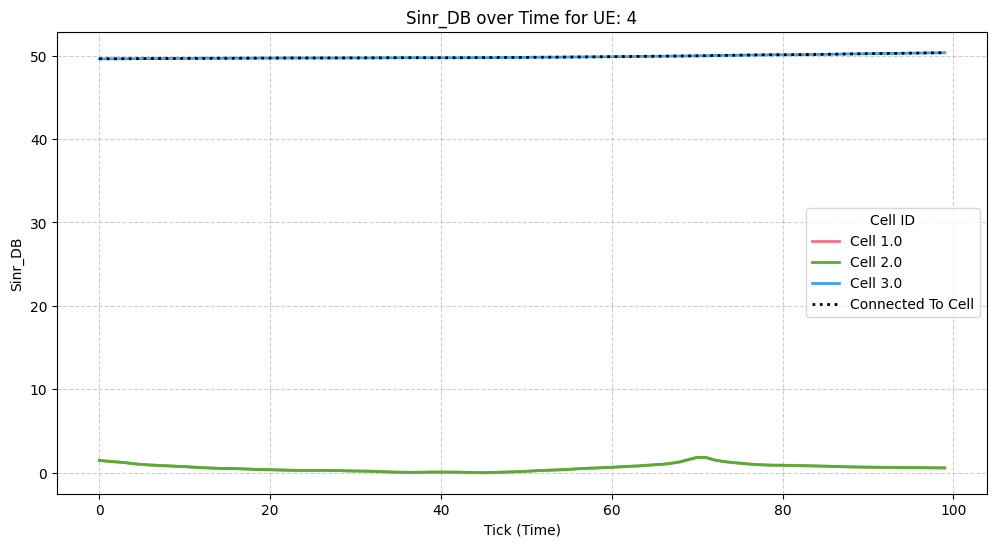

In [168]:
total_plot_rxpower_over_time(df, starting_df, 4)

### Steps to Find Optimum HYSTERESIS & TTT


* call perform_attachment_hyst_ttt on preprocessed ue_data with a random HYST & TTT

* call mro_metric_for_last_20_ticks (need to create) on output from attachment

* change HYST, TTT

* REPEAT

** Goal: To Find Highest Score



In [ ]:
# FIX COUNT_MRO_METRIC